# ***Analyse et Prédiction du Revenu des Adultes***

## 1. Business Understanding


### 1.1 État de l'art

Data Mining and Machine Learning make it possible to discover patterns in large datasets and extract useful information from them. In this project, segmentation and classification are used to analyze socio-economic profiles and study their relationship with income levels.

### 1.2 BOS — Business Objective Statement


BO1: Analyse the socio-economic and professional characteristics of individuals to understand the factors and profiles associated with different income levels.

BO2:Segment individuals into distinct groups based on their demographic, financial, educational, and lifestyle characteristics in order to better understand different population profiles and develop more targeted marketing strategies.

### 1.3 DSO — Data Science Objective

DSO1: Develop classification and clustering models to predict individuals' income categories and identify socio-economic profiles associated with different income levels.

DSO2:Apply the K-Means clustering algorithm to group individuals with similar demographic, financial, educational, and lifestyle characteristics, and identify distinct population segments that can be used to develop targeted marketing strategies.

## 2. Data Understanding


This step aims to understand the dataset, its structure, its variables, and the quality of the available information.

The dataset used in this project is the **Adult Census Income** dataset, extracted from the 1994 United States Census database. It contains demographic, professional, and economic information about individuals.

The objective of this stage is to become familiar with the data before performing the exploration and preparation steps.

### 2.1 Loading the Dataset

The training dataset is stored in the `adult.data` file. Since the original file does not contain column names, the attribute names provided in `adult.names` are assigned manually.

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income"
]

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
x = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
df = x.copy()
df["income"] = y

display(df.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2.2 Dataset Dimensions

The dimensions of the dataset are examined to determine the number of observations and variables available.

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 48842
Number of columns: 15


### 2.3 Variable Description

The dataset contains 14 explanatory variables describing the demographic, professional, and economic characteristics of individuals, as well as one target variable representing the income category.

| Variable | Description | Type | Role |
|---|---|---|---|
| age | Age of the individual | Numerical | Feature |
| workclass | Type of employer | Categorical | Feature |
| fnlwgt | Final sampling weight | Numerical | Feature |
| education | Education level | Categorical | Feature |
| education-num | Numerical representation of education level | Numerical | Feature |
| marital-status | Marital status | Categorical | Feature |
| occupation | Type of occupation | Categorical | Feature |
| relationship | Family relationship | Categorical | Feature |
| race | Race category | Categorical | Feature |
| sex | Sex | Categorical | Feature |
| capital-gain | Capital gain | Numerical | Feature |
| capital-loss | Capital loss | Numerical | Feature |
| hours-per-week | Hours worked per week | Numerical | Feature |
| native-country | Country of origin | Categorical | Feature |
| income | Income category | Categorical | Target |

### 2.4 Dataset Structure

The structure of the dataset is examined to identify the data types of the variables and obtain an overview of the available information.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


### 2.5 Statistical Description

Descriptive statistics are used to obtain an initial overview of the numerical variables. This includes measures such as the mean, standard deviation, minimum, maximum, and quartiles.

In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### 2.6 Categorical Variables

The categorical variables are examined to identify their number of unique values and their most frequent categories.

In [ ]:
df.describe(include="object")

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,47879,48842,48842,47876,48842,48842,48842,48568,48842
unique,9,16,7,15,6,5,2,42,4
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,24720


### 2.7 Missing Values

The dataset uses the character `?` to represent unknown or missing values. These values must be identified before the data preparation stage.

In [ ]:
missing_values = (df == "?").sum()

missing_values[missing_values > 0]

,0
workclass,1836
occupation,1843
native-country,583


In [ ]:
missing_percentage = ((df == "?").sum() / len(df)) * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
occupation,3.773392
workclass,3.759060
native-country,1.193645


### 2.8 Duplicate Observations

Duplicate observations are checked to determine whether the dataset contains identical records that could affect the analysis.

In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 29


### 2.9 Interpretation of Data Understanding

The dataset contains **32,561 observations and 15 variables**, including 14 explanatory variables and one target variable, `income`.

The dataset contains **6 numerical variables** and **9 categorical variables**. The numerical variables describe characteristics such as age, education level, capital gains, capital losses, and hours worked per week. The categorical variables describe professional, demographic, and social characteristics.

The statistical description shows that the average age is approximately **38.6 years**, while the average number of hours worked per week is approximately **40.4 hours**. The `education-num` variable has an average value of approximately **10.1**.

For categorical variables, `Private` is the most frequent workclass, `HS-grad` is the most frequent education level, and `United-States` is the most frequent native country. The target variable `income` contains two categories: `<=50K` and `>50K`, with `<=50K` being the most frequent category.

The dataset also contains missing information represented by the character `?`. Missing values are mainly present in `workclass`, `occupation`, and `native-country`. These missing values will need to be handled during the **Data Preparation** stage.

Finally, **24 duplicate observations** were identified. These duplicates will be considered during the data preparation process to ensure that they do not affect the subsequent analysis and modeling.

Overall, the dataset contains both numerical and categorical information that can be used to study socio-economic characteristics, build an income prediction model, and perform population segmentation.


## 3. Data Exploration


This stage aims to explore the main patterns and relationships present in the dataset. The analysis focuses on the distribution of the target variable and the relationships between income and demographic, educational, and professional characteristics.

The exploration helps identify relevant patterns that will support the business objectives and guide the data preparation and modeling stages.

### 3.1 Income Distribution

The distribution of the target variable `income` is analyzed to understand the proportion of individuals belonging to each income category.


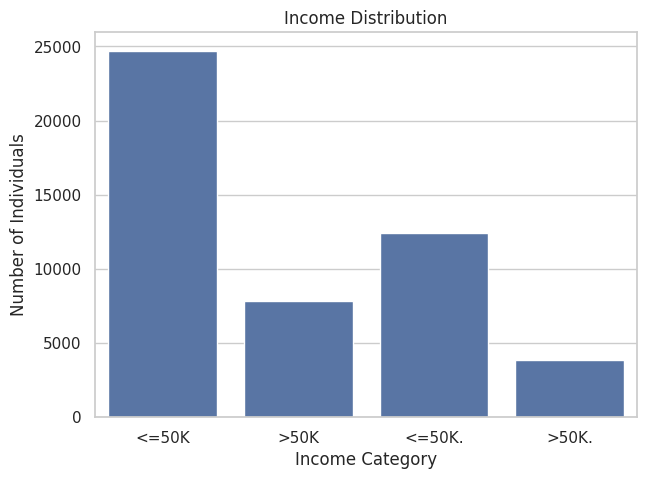

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="income")

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

plt.show()

In [ ]:
income_counts = df["income"].value_counts()
income_percentages = df["income"].value_counts(normalize=True) * 100

print("Number of individuals:")
print(income_counts)

print("\nPercentage distribution:")
print(income_percentages.round(2))

Number of individuals:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

Percentage distribution:
income
<=50K     50.61
<=50K.    25.46
>50K      16.05
>50K.      7.87
Name: proportion, dtype: float64


#### Interpretation

The target variable `income` is not evenly distributed. Among the **32,561 individuals**, **24,720 (75.92%)** belong to the `<=50K` category, while **7,841 (24.08%)** belong to the `>50K` category.

Therefore, the dataset contains a clear imbalance between the two income categories, with the `<=50K` category representing approximately three quarters of the observations.

This distribution is important for the classification stage because the model should be evaluated using metrics that take the class distribution into account rather than relying only on accuracy.


### 3.2 Numerical Variable Exploration

The numerical variables are explored using histograms to understand their distributions, identify possible skewness, and detect unusual values or patterns.


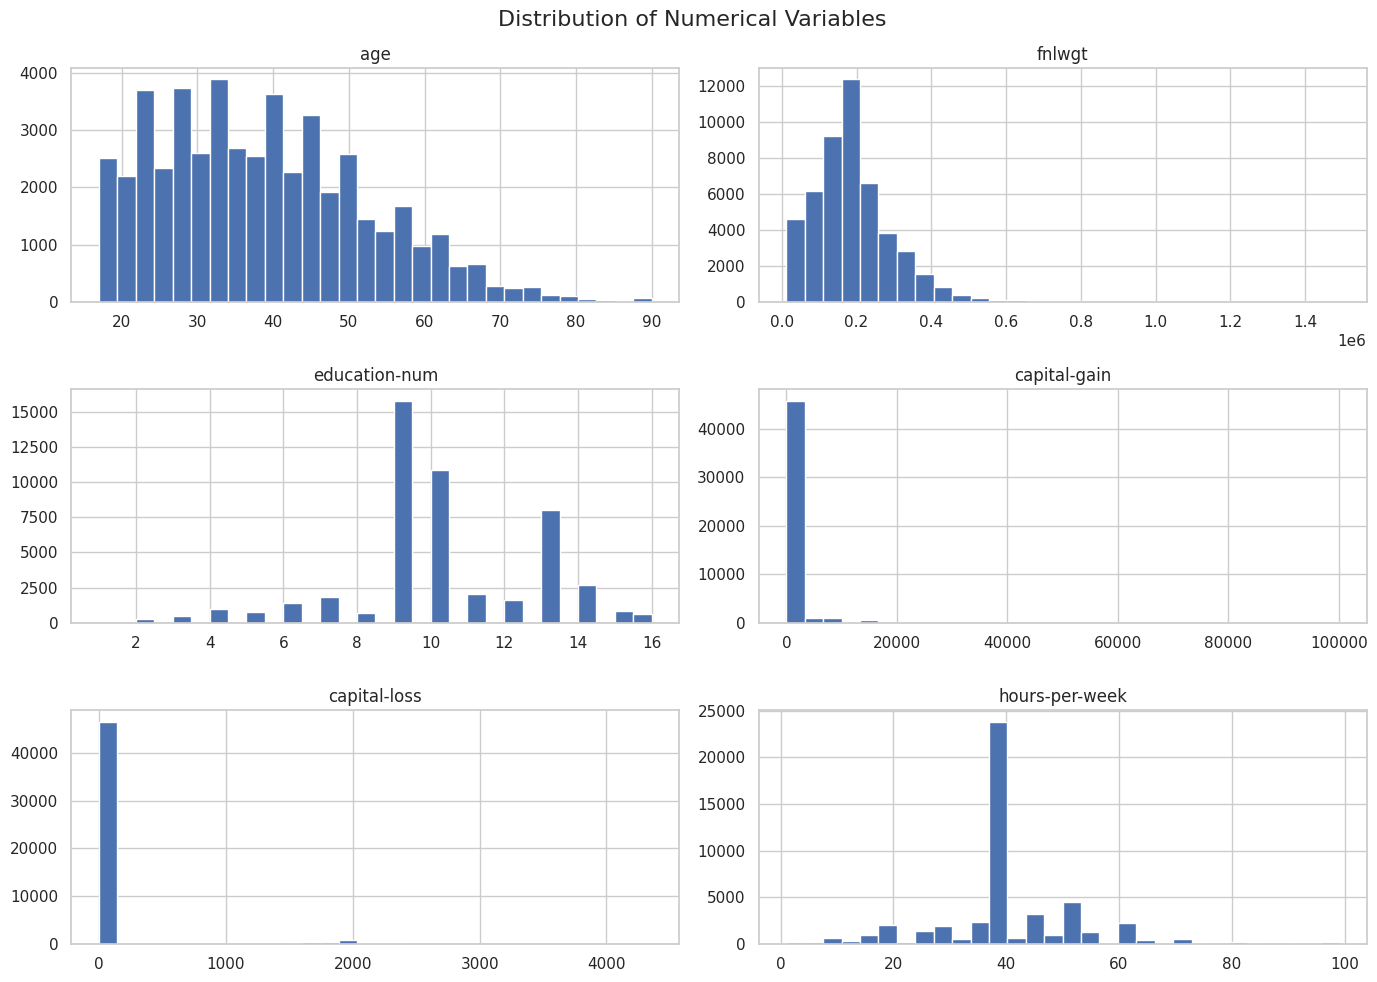

In [ ]:
numerical_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Variables", fontsize=16)
plt.tight_layout()
plt.show()

### 3.3 Categorical Variable Exploration

The categorical variables are explored to identify the most frequent categories and understand the composition of the population according to professional, educational, demographic, and social characteristics.


In [ ]:
categorical_columns = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts().head(10))


workclass
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
?                    1836
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

education
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

marital-status
marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

occupation
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923

### Interpretation

The categorical variables show several important characteristics of the population.

For `workclass`, the **Private** category is largely dominant with **22,696 individuals**, followed by `Self-emp-not-inc` and `Local-gov`. The presence of `?` values confirms that some employment information is missing.

For `education`, `HS-grad` is the most frequent category with **10,501 individuals**, followed by `Some-college` and `Bachelors`. This shows that the dataset contains individuals with a wide range of educational backgrounds.

For `marital-status`, `Married-civ-spouse` is the most frequent category with **14,976 individuals**, followed by `Never-married` with **10,683 individuals**.

The `occupation` variable is relatively diverse. `Prof-specialty`, `Craft-repair`, and `Exec-managerial` are among the most frequent occupations. Missing values are also present in this variable.

For `relationship`, `Husband` is the most frequent category, followed by `Not-in-family` and `Own-child`.

The `race` variable is dominated by the `White` category, representing **27,816 observations**, while the other categories have considerably fewer observations.

The `sex` variable contains two categories, with **21,790 males** and **10,771 females**.

Finally, `native-country` is strongly dominated by `United-States`, with **29,170 individuals**. A smaller number of observations correspond to other countries, and some values are unknown.

Overall, the categorical variables reveal substantial diversity in education, occupation, marital status, and other socio-demographic characteristics. These variables will be particularly useful for understanding population profiles and identifying relationships with income.


### 3.4 Income vs Education

The relationship between education level and income category is analyzed to determine whether educational attainment is associated with differences in income levels.


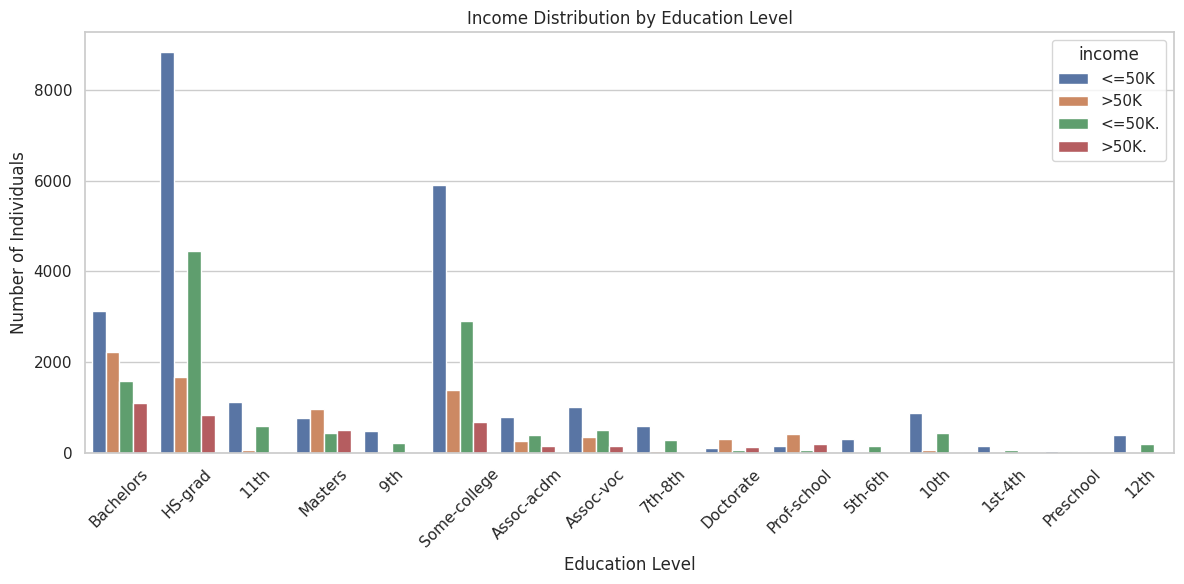

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="education",
    hue="income"
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
education_income = pd.crosstab(
    df["education"],
    df["income"],
    normalize="index"
) * 100

education_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
education,,,,
10th,62.71,31.03,4.46,1.80
11th,61.53,33.39,3.31,1.77
12th,60.88,31.81,5.02,2.28
1st-4th,65.59,31.17,2.43,0.81
5th-6th,62.28,32.42,3.14,2.16
7th-8th,63.46,30.05,4.19,2.30
9th,64.42,30.16,3.57,1.85
Assoc-acdm,50.09,24.11,16.55,9.24
Assoc-voc,49.54,25.13,17.52,7.81


### Interpretation

The results show a clear relationship between education level and income category. In general, individuals with higher levels of education have a greater proportion of incomes above $50K.

For example, **74.09%** of individuals with a Doctorate and **73.44%** of individuals with a Professional School degree belong to the `>50K` category. The proportion is also high for individuals with a Master's degree, at **55.66%**. In comparison, only **6.65%** of individuals with a 10th-grade education and **5.11%** with an 11th-grade education belong to the `>50K` category.

Lower education levels are therefore strongly associated with the `<=50K` income category, while higher education levels show a substantially higher proportion of individuals earning more than $50K.

This suggests that **education level is an important socio-economic factor associated with income** and should be considered in the subsequent classification and segmentation analyses.


### 3.5 Income vs Age

The relationship between age and income category is analyzed to determine whether income levels vary across different age groups.


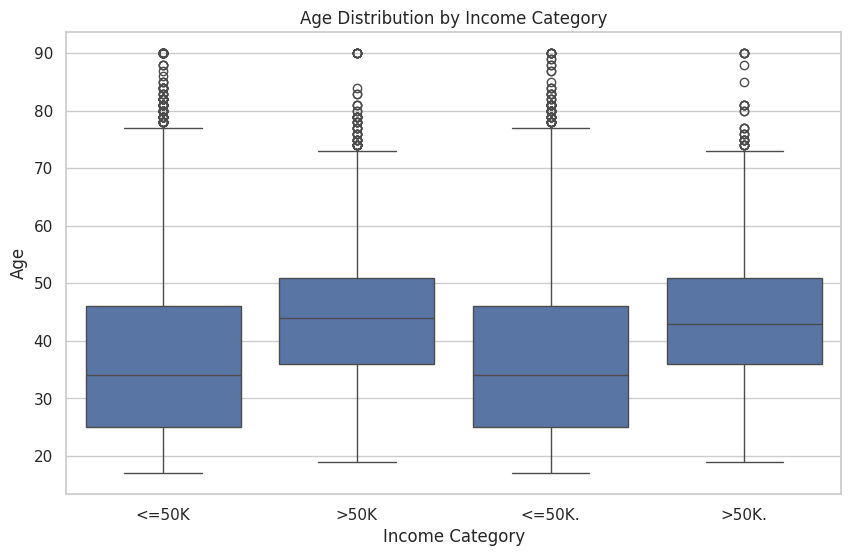

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="income",
    y="age"
)

plt.title("Age Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Age")

plt.show()

In [ ]:
df.groupby("income")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,36.783738,14.020088,17.0,25.0,34.0,46.0,90.0
<=50K.,12435.0,37.048010,14.268633,17.0,25.0,34.0,46.0,90.0
>50K,7841.0,44.249841,10.519028,19.0,36.0,44.0,51.0,90.0
>50K.,3846.0,44.326833,10.641164,19.0,36.0,43.0,51.0,90.0


### Interpretation

The results show a noticeable relationship between age and income category. Individuals belonging to the `>50K` income category have a higher average age than those in the `<=50K` category.

The average age is **44.25 years** for individuals earning more than 50K, compared with **36.78 years** for individuals earning 50K or less. The median age also differs, with a median of **44 years** for the `>50K` group and **34 years** for the `<=50K` group.

The middle 50% of individuals in the `>50K` category are between **36 and 51 years old**, while those in the `<=50K` category are between **25 and 46 years old**.

These results suggest that **age is an important factor associated with income**, with higher-income individuals tending to be older than lower-income individuals. However, age alone does not determine income, as both income categories contain individuals across a wide age range.

Therefore, age should be considered alongside other socio-economic and professional variables in the subsequent classification and segmentation analyses.


### 3.6 Income vs Occupation

The relationship between occupation and income category is analyzed to identify whether certain professional occupations are more strongly associated with higher income levels.


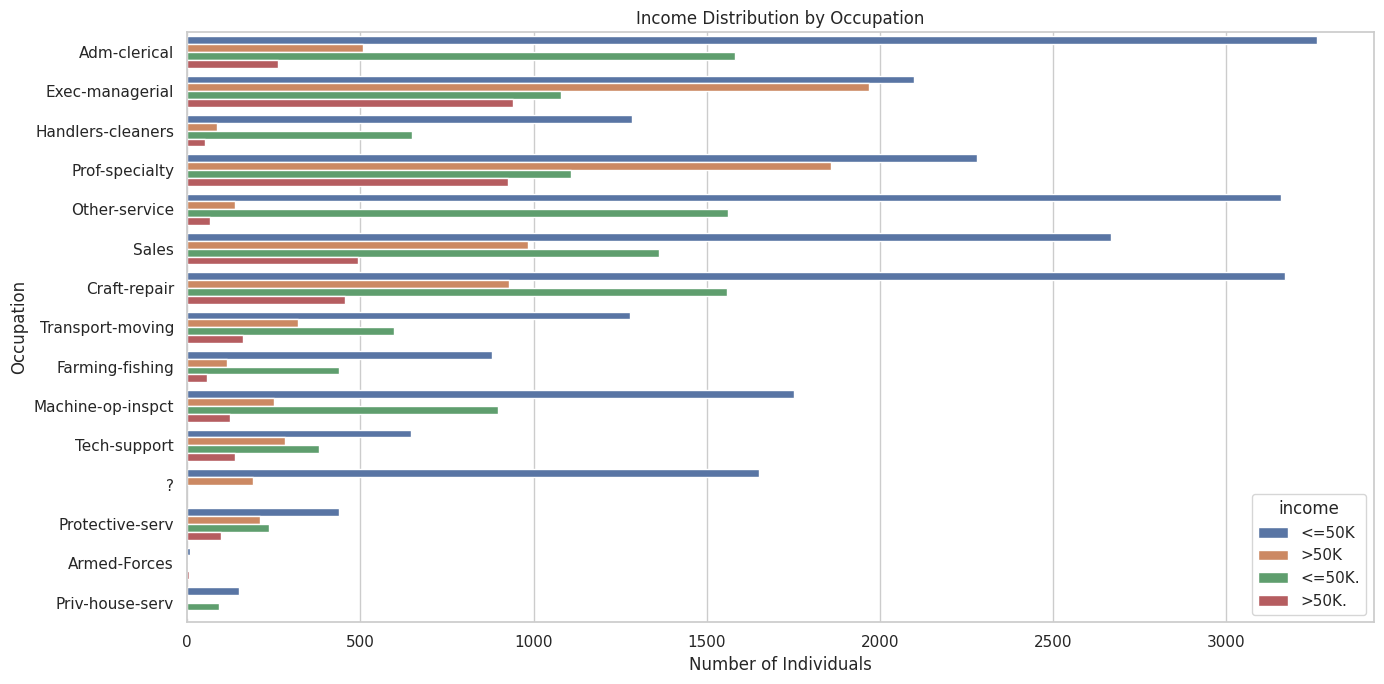

In [ ]:
plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="occupation",
    hue="income"
)

plt.title("Income Distribution by Occupation")
plt.xlabel("Number of Individuals")
plt.ylabel("Occupation")

plt.tight_layout()
plt.show()

In [ ]:
occupation_income = pd.crosstab(
    df["occupation"],
    df["income"],
    normalize="index"
) * 100

occupation_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
occupation,,,,
?,89.64,0.00,10.36,0.00
Adm-clerical,58.15,28.16,9.04,4.65
Armed-Forces,53.33,13.33,6.67,26.67
Craft-repair,51.87,25.51,15.20,7.43
Exec-managerial,34.47,17.75,32.34,15.45
Farming-fishing,58.99,29.40,7.72,3.89
Handlers-cleaners,61.97,31.37,4.15,2.51
Machine-op-inspct,57.97,29.72,8.27,4.04
Other-service,64.15,31.71,2.78,1.36


### Interpretation

The results show that income distribution varies considerably across occupations. Some professional categories have a much higher proportion of individuals earning more than 50K, while others are strongly concentrated in the `<=50K` category.

The highest proportions of individuals earning more than 50K are observed among **Exec-managerial (48.40%)**, **Prof-specialty (44.90%)**, and **Protective-serv (32.51%)**. Tech-support also has a relatively high proportion of individuals in the `>50K` category, at **30.50%**.

In contrast, occupations such as **Priv-house-serv (0.67%)**, **Other-service (4.16%)**, and **Handlers-cleaners (6.28%)** have very low proportions of individuals earning more than 50K. The `?` category also shows a majority of individuals in the `<=50K` category, with **89.64%**.

Overall, the results suggest that **occupation is an important socio-economic and professional factor associated with income level**. Higher proportions of `>50K` income are generally observed in managerial and specialized professional occupations, whereas service and lower-skilled occupations are more concentrated in the `<=50K` category.

This variable will therefore be particularly useful for the subsequent **income classification and clustering analyses**.


### 3.7 Income vs Hours-per-week

The relationship between weekly working hours and income category is analyzed to determine whether individuals working longer hours tend to have a higher proportion of incomes above $50K.


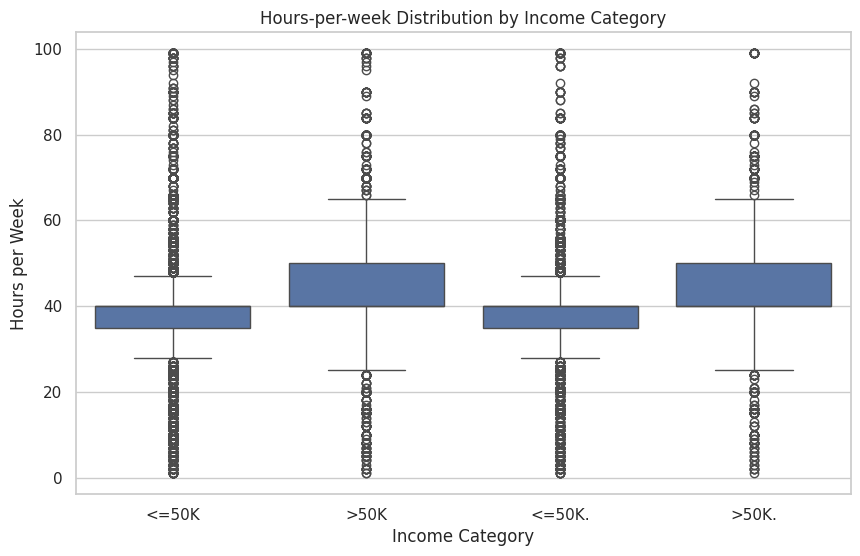

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Hours-per-week Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")

plt.show()

In [ ]:
df.groupby("income")["hours-per-week"].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,38.840210,12.318995,1.0,35.0,40.0,40.0,99.0
<=50K.,12435.0,38.839727,12.432257,1.0,35.0,40.0,40.0,99.0
>50K,7841.0,45.473026,11.012971,1.0,40.0,40.0,50.0,99.0
>50K.,3846.0,45.411856,11.250264,1.0,40.0,40.0,50.0,99.0


### Interpretation

The results show a noticeable difference in weekly working hours between the two income categories. Individuals earning more than 50K work an average of **45.47 hours per week**, compared with **38.84 hours per week** for individuals earning 50K or less.

The median is **40 hours** for both income categories, indicating that a typical individual in both groups works around a standard full-time schedule. However, the `>50K` group has a higher upper quartile, with **75% of individuals working 50 hours or fewer**, compared with **40 hours or fewer** for the `<=50K` group.

The results suggest that **working hours are associated with income level**, with higher-income individuals tending to work more hours per week on average. However, the overlap between the two groups indicates that working hours alone cannot explain income differences.

Therefore, `hours-per-week` can be considered an additional relevant variable for the subsequent **classification and clustering analyses**.


### 3.8 Income vs Marital Status

The relationship between marital status and income category is analyzed to determine whether income levels differ according to an individual's marital status.


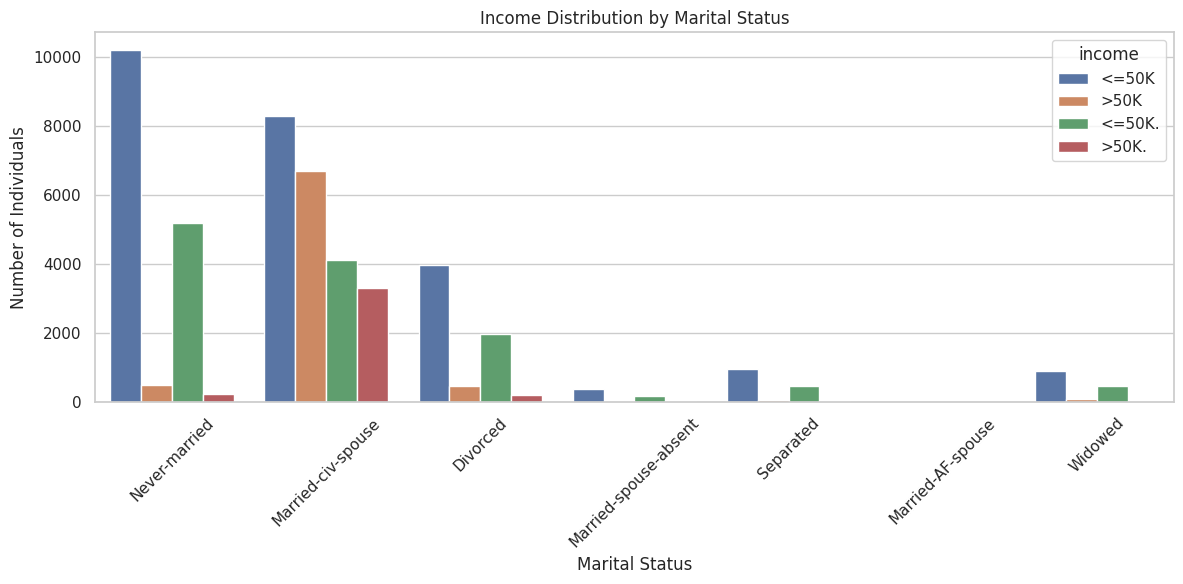

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="marital-status",
    hue="income"
)

plt.title("Income Distribution by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
marital_income = pd.crosstab(
    df["marital-status"],
    df["income"],
    normalize="index"
) * 100

marital_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
marital-status,,,,
Divorced,60.00,29.88,6.98,3.14
Married-AF-spouse,35.14,27.03,27.03,10.81
Married-civ-spouse,37.02,18.37,29.90,14.71
Married-spouse-absent,61.15,29.62,5.41,3.82
Never-married,63.24,32.21,3.05,1.50
Separated,62.68,30.85,4.31,2.16
Widowed,59.82,31.75,5.60,2.83


### Interpretation

The results show a clear difference in income distribution across marital-status categories. Individuals in the married categories have substantially higher proportions of incomes above 50K compared with individuals in the other categories.

The highest proportions of `>50K` income are observed among **Married-civ-spouse (44.68%)** and **Married-AF-spouse (43.48%)**. In comparison, only **4.60%** of individuals who have never married belong to the `>50K` category.

The other categories are also strongly concentrated in the `<=50K` category. For example, **95.40%** of Never-married individuals, **93.56%** of Separated individuals, and **91.87%** of Married-spouse-absent individuals belong to the `<=50K` category.

Overall, the results suggest that **marital status is associated with income level**, particularly because the married categories show a substantially higher proportion of individuals earning more than 50K. However, this relationship should not be interpreted as causation, since marital status may also be related to other factors such as age, education, occupation, and working hours.

Therefore, marital status is a relevant variable to consider in the subsequent **classification and clustering analyses**.


### 3.9 Income vs Capital Gain

The relationship between capital gain and income category is analyzed to determine whether individuals with higher capital gains are more likely to belong to the `>50K` income category.


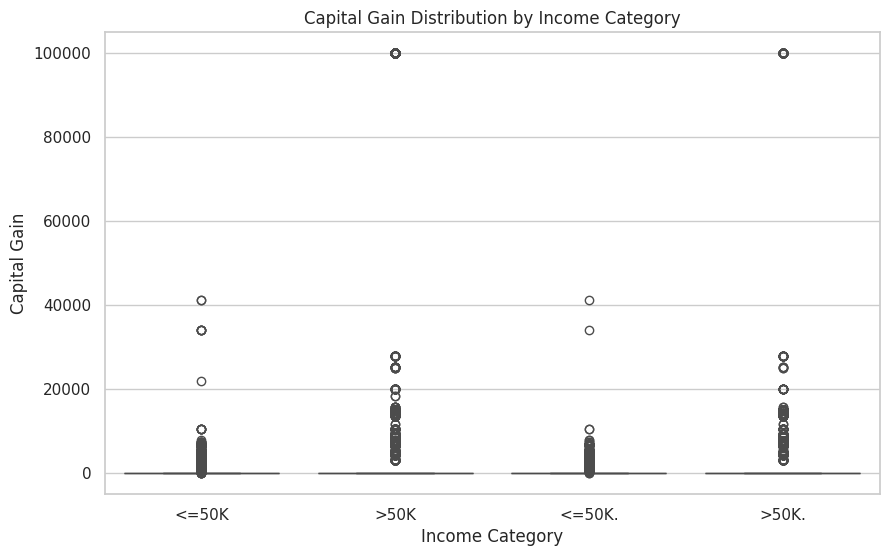

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="income",
    y="capital-gain"
)

plt.title("Capital Gain Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Capital Gain")

plt.show()

In [ ]:
df.groupby("income")["capital-gain"].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,148.752468,963.139307,0.0,0.0,0.0,0.0,41310.0
<=50K.,12435.0,143.547004,881.986946,0.0,0.0,0.0,0.0,41310.0
>50K,7841.0,4006.142456,14570.378951,0.0,0.0,0.0,0.0,99999.0
>50K.,3846.0,4115.832033,15131.318541,0.0,0.0,0.0,0.0,99999.0


### Interpretation

The results show a strong difference in capital gain between the two income categories. Individuals in the `<=50K` category have an average capital gain of approximately **148.75**, while individuals in the `>50K` category have a much higher average of approximately **4,006.14**.

However, the median and the three quartiles are **0 for both income categories**, indicating that most individuals in the dataset have no capital gain. The difference in the means is therefore mainly influenced by individuals who have relatively large capital gains.

The maximum capital gain is **41,310** for the `<=50K` category and **99,999** for the `>50K` category. This indicates that very high capital gains are more strongly represented among individuals earning more than 50K.

Overall, the results suggest that **capital gain is strongly associated with income category**, although the large number of zero values and the presence of extreme values make the distribution highly skewed. This variable may therefore provide useful information for the subsequent **income classification and clustering analyses**.


### 3.10 Income vs Capital Loss

The relationship between capital loss and income category is analyzed to determine whether capital losses differ between individuals belonging to the two income categories.


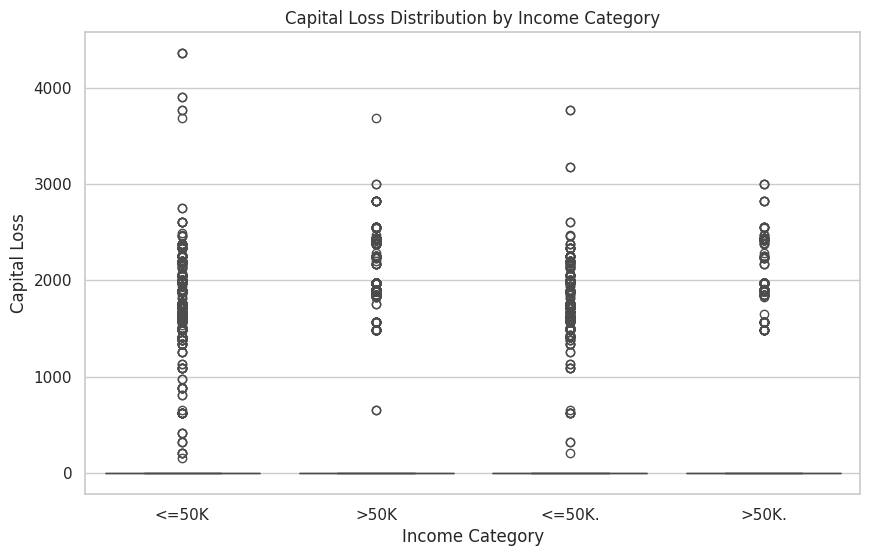

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="income",
    y="capital-loss"
)

plt.title("Capital Loss Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Capital Loss")

plt.show()

In [ ]:
df.groupby("income")["capital-loss"].describe()

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,24720.0,53.142921,310.755769,0.0,0.0,0.0,0.0,4356.0
<=50K.,12435.0,56.157780,318.359311,0.0,0.0,0.0,0.0,3770.0
>50K,7841.0,195.001530,595.487574,0.0,0.0,0.0,0.0,3683.0
>50K.,3846.0,190.526781,588.609963,0.0,0.0,0.0,0.0,3004.0


### Interpretation

The results show a difference in capital loss between the two income categories. Individuals in the `<=50K` category have an average capital loss of approximately **53.14**, while individuals in the `>50K` category have a higher average of approximately **195.00**.

However, the median and all three quartiles are **0 for both income categories**. This indicates that most individuals in the dataset have no capital loss. The higher mean values are therefore influenced by a smaller number of individuals who report capital losses.

The maximum capital loss is **4,356** for the `<=50K` category and **3,683** for the `>50K` category. Despite the lower maximum, the `>50K` group has a substantially higher average capital loss.

Overall, the results suggest that **capital loss is associated with income category**, with higher average capital losses observed among individuals earning more than 50K. However, because the variable contains many zero values and is highly skewed, it should be interpreted carefully and considered alongside other socio-economic and financial variables.


### 3.11 Income vs Relationship

The relationship between relationship status and income category is analyzed to determine whether income levels vary according to an individual's position within their household or family structure.


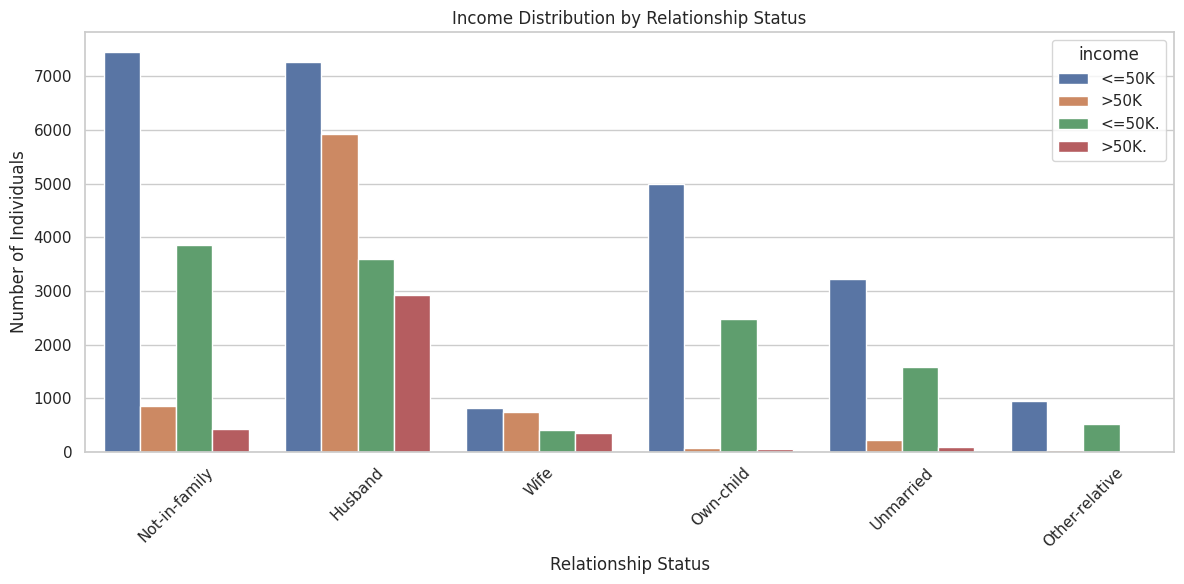

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="relationship",
    hue="income"
)

plt.title("Income Distribution by Relationship Status")
plt.xlabel("Relationship Status")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
relationship_income = pd.crosstab(
    df["relationship"],
    df["income"],
    normalize="index"
) * 100

relationship_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
relationship,,,,
Husband,36.90,18.23,30.02,14.85
Not-in-family,59.20,30.66,6.80,3.34
Other-relative,62.68,33.86,2.46,1.00
Own-child,65.97,32.57,0.88,0.58
Unmarried,62.99,30.99,4.25,1.78
Wife,35.31,17.80,31.96,14.93


### Interpretation

The results show a clear relationship between relationship status and income category. **Wife (47.51%)** and **Husband (44.86%)** have the highest proportions of individuals earning more than $50K.

In contrast, **Own-child (1.32%)**, **Other-relative (3.77%)**, and **Unmarried (6.33%)** are strongly concentrated in the `<=50K` category.

Overall, relationship status appears to be an important factor associated with income and can contribute to the subsequent **classification and clustering analyses**.


### 3.12 Income vs Workclass

The relationship between workclass and income category is analyzed to determine whether income levels vary according to employment sector.


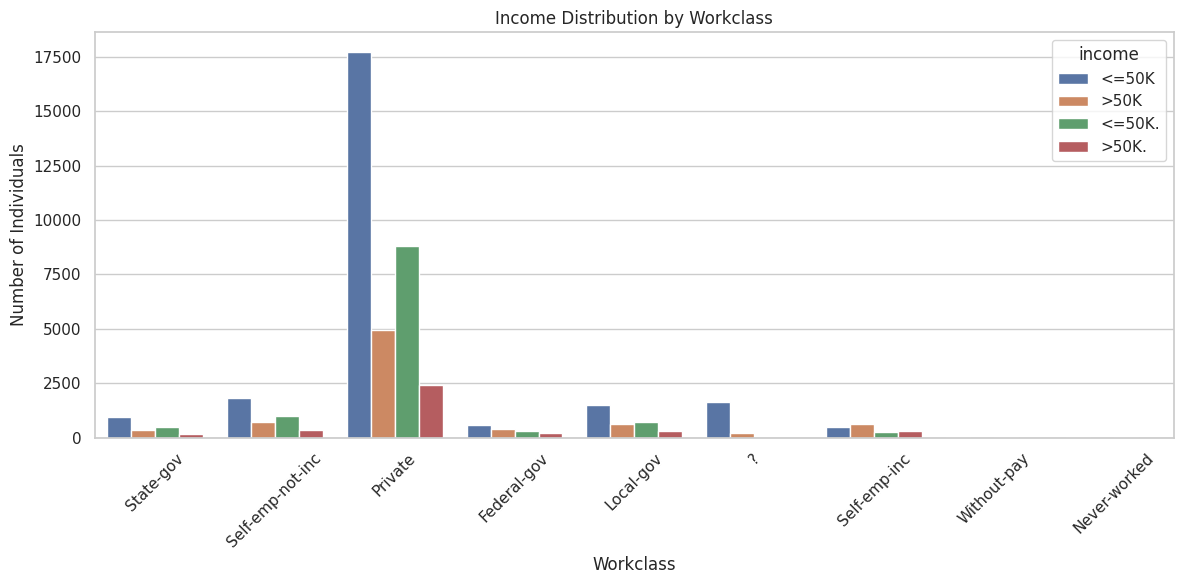

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="workclass",
    hue="income"
)

plt.title("Income Distribution by Workclass")
plt.xlabel("Workclass")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
workclass_income = pd.crosstab(
    df["workclass"],
    df["income"],
    normalize="index"
) * 100

workclass_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
workclass,,,,
?,89.60,0.00,10.40,0.00
Federal-gov,41.13,19.69,25.91,13.27
Local-gov,47.07,23.37,19.67,9.89
Never-worked,70.00,30.00,0.00,0.00
Private,52.30,25.91,14.64,7.15
Self-emp-inc,29.14,15.52,36.70,18.64
Self-emp-not-inc,47.05,25.06,18.75,9.14
State-gov,47.70,25.54,17.82,8.93
Without-pay,66.67,23.81,0.00,9.52


### Interpretation

The results show a clear difference in income distribution across workclass categories. **Self-emp-inc** has the highest proportion of individuals earning more than 50K (**55.73%**), followed by **Federal-gov (38.65%)**.

In contrast, **Never-worked** and **Without-pay** are entirely concentrated in the `<=50K` category. Overall, **workclass is an important factor associated with income level** and can be useful for the subsequent classification and clustering analyses.


### 3.13 Income vs Gender

The relationship between Gender and income category is analyzed to determine whether income levels vary between male and female individuals.


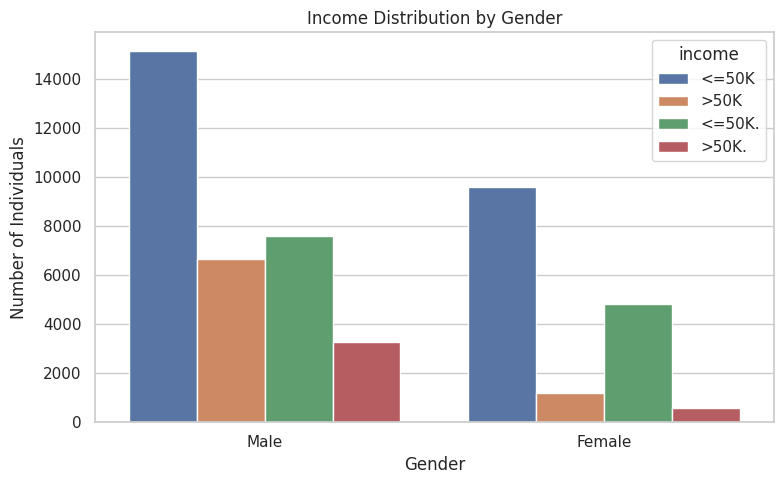

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sex", hue="income")

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

In [ ]:
gender_income = pd.crosstab(df["sex"], df["income"], normalize="index") * 100
gender_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
sex,,,,
Female,59.24,29.84,7.28,3.64
Male,46.33,23.29,20.40,9.97


### Interpretation

The results show a difference in income distribution between the two gender categories. **30.57% of males** belong to the `>50K` category, compared with **10.95% of females**.

Overall, **gender is associated with income level** in this dataset and may provide useful information for the subsequent classification and clustering analyses.


### 3.14 Income vs Native Country

The relationship between native country and income category is analyzed to identify potential differences in income levels across countries of origin.


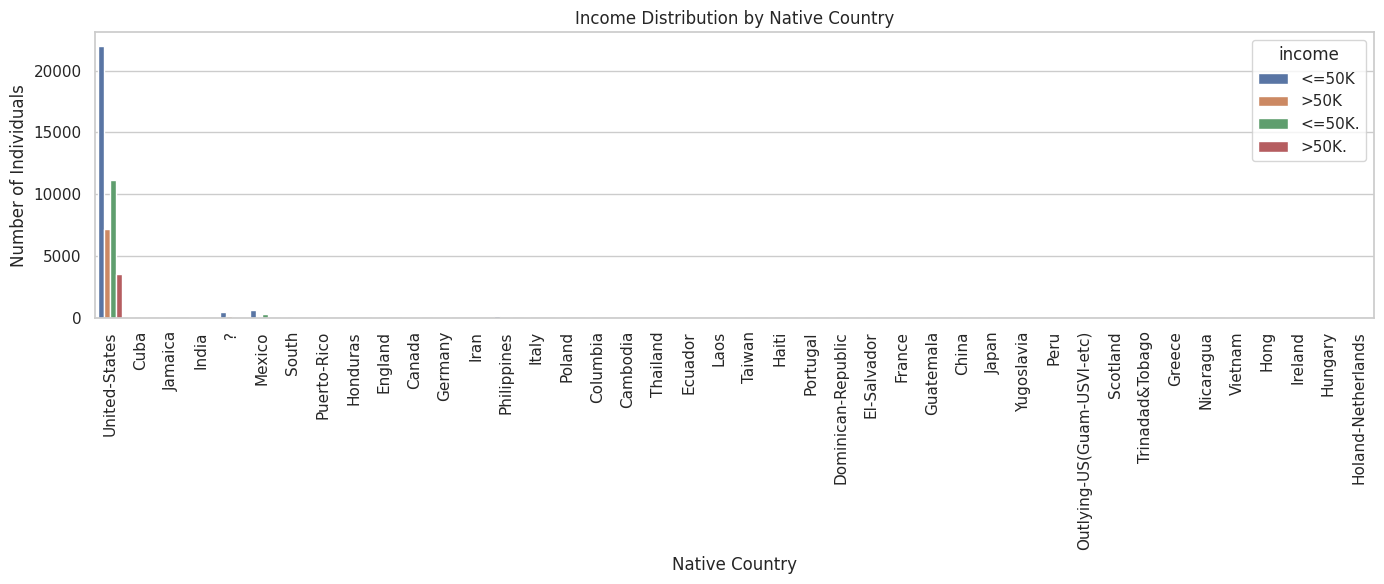

In [ ]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x="native-country", hue="income")

plt.title("Income Distribution by Native Country")
plt.xlabel("Native Country")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
country_income = pd.crosstab(
    df["native-country"],
    df["income"],
    normalize="index"
) * 100

country_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
native-country,,,,
?,74.96,0.00,25.04,0.00
Cambodia,42.86,25.00,25.00,7.14
Canada,45.05,20.33,21.43,13.19
China,45.08,25.41,16.39,13.11
Columbia,67.06,28.24,2.35,2.35
Cuba,50.72,24.64,18.12,6.52
Dominican-Republic,66.02,29.13,1.94,2.91
Ecuador,53.33,33.33,8.89,4.44
El-Salvador,62.58,30.32,5.81,1.29


### Interpretation

The results show differences in income distribution across native-country categories. Higher proportions of `>50K` are observed for **France (41.38%)**, **Iran (41.86%)**, **India (40.00%)**, and **Taiwan (39.22%)**.

In contrast, countries such as **Dominican-Republic (2.86%)**, **Columbia (3.39%)**, and **Mexico (5.13%)** have much lower proportions of individuals earning more than 50K. Overall, native country may be associated with income level, but the results should be interpreted carefully because some countries have relatively few observations.


### 3.15 Income vs Race

The relationship between race and income category is analyzed to identify differences in income distribution across population groups.


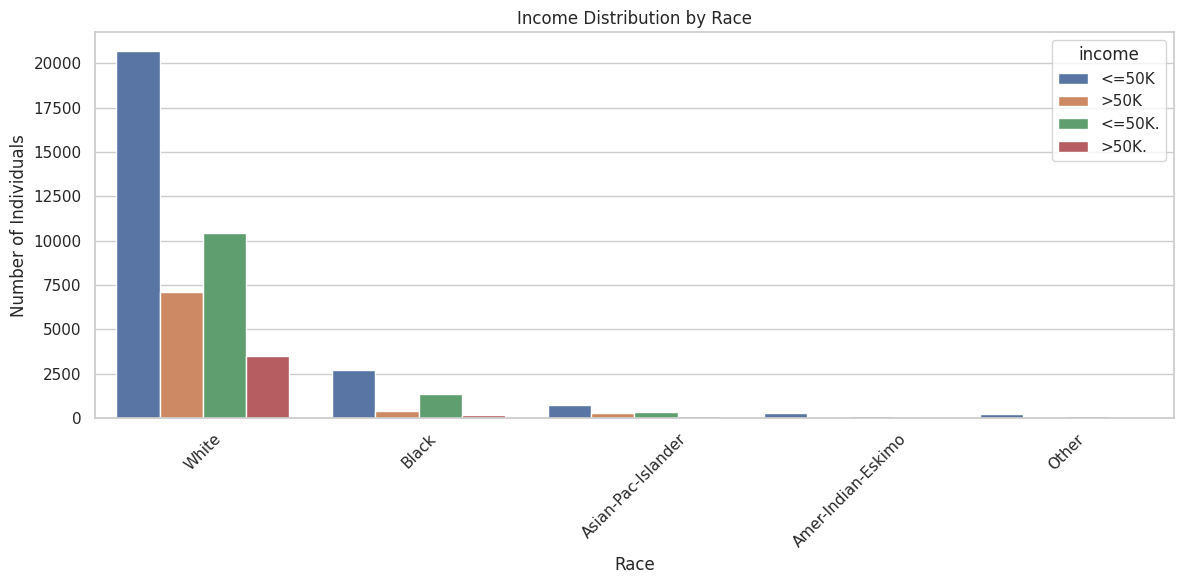

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="race", hue="income")

plt.title("Income Distribution by Race")
plt.xlabel("Race")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
race_income = pd.crosstab(
    df["race"],
    df["income"],
    normalize="index"
) * 100

race_income.round(2)

income,<=50K,<=50K.,>50K,>50K.
race,,,,
Amer-Indian-Eskimo,58.51,29.79,7.66,4.04
Asian-Pac-Islander,50.23,22.84,18.17,8.76
Black,58.42,29.50,8.26,3.82
Other,60.59,27.09,6.16,6.16
White,49.56,25.04,17.04,8.36


### Interpretation

The results show differences in income distribution across racial categories. **Asian-Pac-Islander (26.56%)** and **White (25.59%)** have the highest proportions of individuals earning more than 50K.

In comparison, **Other (9.23%)**, **Amer-Indian-Eskimo (11.58%)**, and **Black (12.39%)** have lower proportions in the `>50K` category. Overall, race shows an association with income in this dataset and can be considered in the subsequent analyses.


### 3.16 Correlation Analysis

A correlation analysis is performed to examine the relationships between the numerical variables and identify variables that may be relevant for the subsequent predictive modeling and clustering tasks.


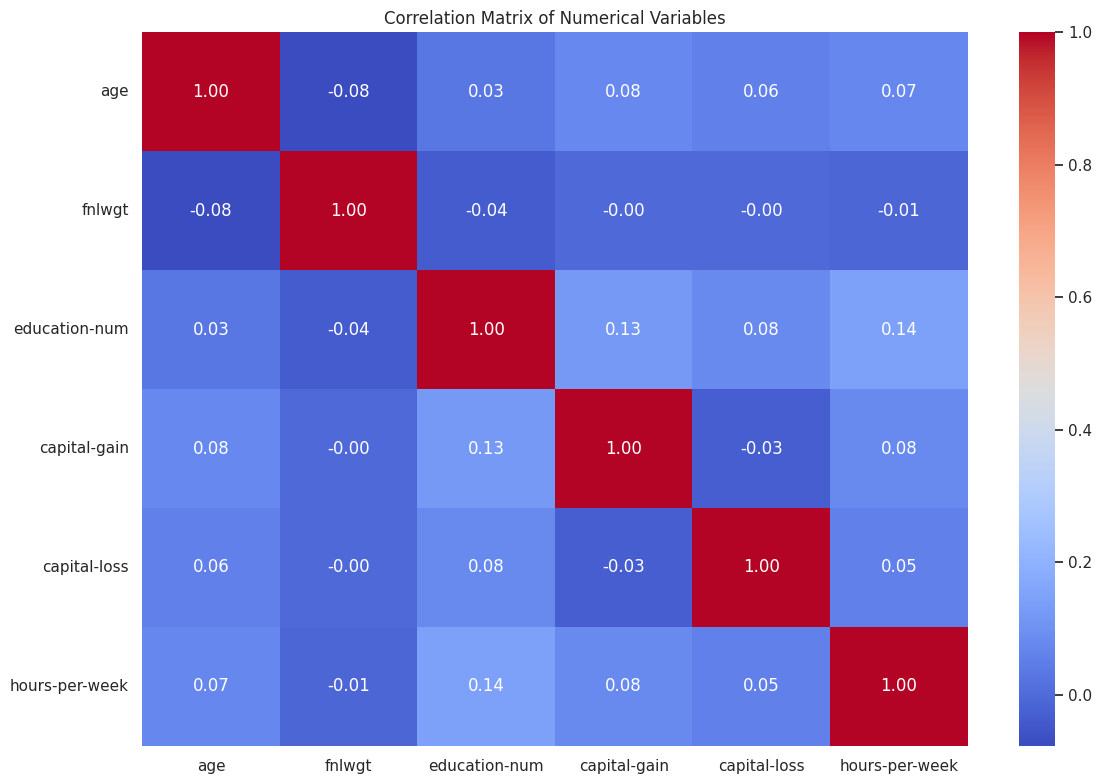

In [ ]:
plt.figure(figsize=(12, 8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### 3.17 EDA Summary

The exploratory analysis shows that income is associated with several socio-economic and professional characteristics. **Education, occupation, age, workclass, marital status, relationship, working hours, and capital gains/losses** show noticeable differences between the `<=50K` and `>50K` categories.

These findings confirm that income depends on multiple characteristics rather than a single variable. The identified relationships will guide the **data preprocessing, classification model, and clustering analysis** in the next stages of the project.


## 4. Data Preparation


In [ ]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from ucimlrepo import fetch_ucirepo
from scipy.stats import chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [ ]:
sns.set_theme(style="whitegrid"); pd.set_option("display.max_columns", 60)
RANDOM_STATE = 42

adult = fetch_ucirepo(id=2)
x = adult.data.features
y = adult.data.targets
print(adult.metadata["name"], "| rows:", x.shape[0], "| features:", x.shape[1])
print(adult.variables)

Adult | rows: 48842 | features: 14
              name     role         type      demographic  \
0              age  Feature      Integer              Age   
1        workclass  Feature  Categorical           Income   
2           fnlwgt  Feature      Integer             None   
3        education  Feature  Categorical  Education Level   
4    education-num  Feature      Integer  Education Level   
5   marital-status  Feature  Categorical            Other   
6       occupation  Feature  Categorical            Other   
7     relationship  Feature  Categorical            Other   
8             race  Feature  Categorical             Race   
9              sex  Feature       Binary              Sex   
10    capital-gain  Feature      Integer             None   
11    capital-loss  Feature      Integer             None   
12  hours-per-week  Feature      Integer             None   
13  native-country  Feature  Categorical            Other   
14          income   Target       Binary          

###4.1 Cleaning

In [ ]:
df = pd.concat([x, y], axis=1).copy()
df.columns = df.columns.str.replace("-", "_")          # safe column names

# strip whitespace and turn "?" into real missing values
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].str.strip().replace({"?": np.nan, "": np.nan})

# the test split of Adult writes labels as "<=50K." / ">50K." -> harmonise
df["income"] = df["income"].str.replace(".", "", regex=False)
print("Income labels:", df["income"].unique())

# duplicates
n0 = len(df); df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {n0 - len(df)} duplicate rows")

# sentinel in capital_gain: 99999 is a top-coded value, keep a flag
df["capital_gain_capped"] = (df["capital_gain"] == 99999).astype(int)

# dtype sanity
num_raw = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
df[num_raw] = df[num_raw].apply(pd.to_numeric, errors="coerce")

# education and education_num carry the same information -> keep numeric only
print("education vs education_num consistent:",
      df.groupby("education")["education_num"].nunique().max() == 1)
df = df.drop(columns=["education"])

miss = df.isna().sum().to_frame("missing"); miss["pct"] = (miss["missing"] / len(df) * 100).round(2)
miss[miss["missing"] > 0]

Income labels: ['<=50K' '>50K']
Removed 52 duplicate rows
education vs education_num consistent: True


,missing,pct
workclass,2795,5.73
occupation,2805,5.75
native_country,856,1.75


###4.2 Filling gaps

- **Numeric columns:** mean imputation (the Adult numeric columns are complete, but the step makes the pipeline safe for new data).
- **Categorical columns** (`workclass`, `occupation`, `native_country`): predicted with a Random Forest trained on the fully observed columns. We report hold-out accuracy so you know how much to trust the fill.
- A `*_missing` flag is kept because "being unknown" is often informative.

In [ ]:
# missing flags BEFORE filling
for c in ["workclass", "occupation", "native_country"]:
    df[f"{c}_missing"] = df[c].isna().astype(int)

# 1) numeric -> mean
for c in df.select_dtypes(include="number").columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mean())

# 2) categorical -> model prediction using columns that are always observed
base_cols = ["age", "education_num", "marital_status", "relationship", "race", "sex",
             "capital_gain", "capital_loss", "hours_per_week"]

def encode_base(d):
    b = d[base_cols].copy()
    for c in b.select_dtypes("object"):
        b[c] = b[c].astype("category").cat.codes
    return b

def impute_with_model(d, col):
    miss_mask = d[col].isna()
    if not miss_mask.any():
        return d[col]
    B = encode_base(d)
    Xtr, Xv, ytr, yv = train_test_split(B[~miss_mask], d.loc[~miss_mask, col],
                                        test_size=0.2, random_state=RANDOM_STATE)
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3, n_jobs=-1,
                                random_state=RANDOM_STATE).fit(Xtr, ytr)
    majority = (yv == ytr.mode()[0]).mean()
    print(f"{col:15s} filled {miss_mask.sum():5d} rows | hold-out acc {rf.score(Xv, yv):.3f} "
          f"(majority baseline {majority:.3f})")
    rf.fit(B[~miss_mask], d.loc[~miss_mask, col])
    out = d[col].copy(); out[miss_mask] = rf.predict(B[miss_mask])
    return out

df_raw_occ = df["occupation"].copy()                       # keep original (with NaN) for objective 3
for c in ["workclass", "occupation", "native_country"]:
    df[c] = impute_with_model(df, c)

assert df.drop(columns=["income"]).isna().sum().sum() == 0
print("Remaining missing values:", int(df.isna().sum().sum()))

workclass       filled  2795 rows | hold-out acc 0.733 (majority baseline 0.732)
occupation      filled  2805 rows | hold-out acc 0.326 (majority baseline 0.136)
native_country  filled   856 rows | hold-out acc 0.918 (majority baseline 0.911)
Remaining missing values: 0


### 4.3 Feature engineering


New features by theme: financial, education, lifestyle/work, household, demographic grouping.

In [ ]:
fe = df.copy()

# financial
fe["capital_net"]       = fe["capital_gain"] - fe["capital_loss"]
fe["log_capital_gain"]  = np.log1p(fe["capital_gain"])
fe["log_capital_loss"]  = np.log1p(fe["capital_loss"])
fe["has_capital_gain"]  = (fe["capital_gain"] > 0).astype(int)
fe["has_capital_loss"]  = (fe["capital_loss"] > 0).astype(int)

# education / career stage
fe["higher_edu"]        = (fe["education_num"] >= 13).astype(int)            # bachelor's or above
fe["experience_proxy"]  = (fe["age"] - fe["education_num"] - 6).clip(lower=0) # years since schooling
fe["age_group"]         = pd.cut(fe["age"], [0, 24, 34, 44, 54, 64, 120],
                                 labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"])

# lifestyle / work intensity: 0 part-time, 1 full-time, 2 overtime
fe["work_intensity"]    = pd.cut(fe["hours_per_week"], [-1, 34, 45, 200], labels=[0, 1, 2]).astype(int)

# household
fe["is_married"]        = fe["marital_status"].isin(["Married-civ-spouse", "Married-AF-spouse"]).astype(int)
fe["marital_group"]     = fe["marital_status"].map({
    "Married-civ-spouse": "Married", "Married-AF-spouse": "Married", "Married-spouse-absent": "Married",
    "Never-married": "Never-married",
    "Divorced": "Previously-married", "Separated": "Previously-married", "Widowed": "Previously-married"})

# demographics
fe["is_male"]           = (fe["sex"] == "Male").astype(int)
fe["is_us_native"]      = (fe["native_country"] == "United-States").astype(int)
region_map = {
    "United-States": "North-America", "Canada": "North-America", "Outlying-US(Guam-USVI-etc)": "North-America",
    "Mexico": "Latin-America", "Puerto-Rico": "Latin-America", "Cuba": "Latin-America", "Jamaica": "Latin-America",
    "Dominican-Republic": "Latin-America", "Haiti": "Latin-America", "Guatemala": "Latin-America",
    "Honduras": "Latin-America", "El-Salvador": "Latin-America", "Nicaragua": "Latin-America",
    "Columbia": "Latin-America", "Ecuador": "Latin-America", "Peru": "Latin-America",
    "Trinadad&Tobago": "Latin-America",
    "England": "Europe", "Germany": "Europe", "France": "Europe", "Italy": "Europe", "Poland": "Europe",
    "Portugal": "Europe", "Ireland": "Europe", "Greece": "Europe", "Scotland": "Europe",
    "Yugoslavia": "Europe", "Hungary": "Europe", "Holand-Netherlands": "Europe",
    "India": "Asia", "China": "Asia", "Japan": "Asia", "Taiwan": "Asia", "Philippines": "Asia",
    "Vietnam": "Asia", "Iran": "Asia", "Thailand": "Asia", "Cambodia": "Asia", "Laos": "Asia",
    "Hong": "Asia", "South": "Asia"}
fe["region"] = fe["native_country"].map(region_map).fillna("Other")

# employment type
fe["workclass_group"]   = fe["workclass"].map({
    "Private": "Private", "Self-emp-not-inc": "Self-employed", "Self-emp-inc": "Self-employed",
    "Federal-gov": "Government", "State-gov": "Government", "Local-gov": "Government",
    "Without-pay": "Unpaid", "Never-worked": "Unpaid"})

# occupation family (only used where occupation is NOT the target)
fe["collar"] = fe["occupation"].map({
    "Exec-managerial": "White-collar", "Prof-specialty": "White-collar", "Adm-clerical": "White-collar",
    "Sales": "White-collar", "Tech-support": "White-collar",
    "Craft-repair": "Blue-collar", "Machine-op-inspct": "Blue-collar", "Transport-moving": "Blue-collar",
    "Handlers-cleaners": "Blue-collar", "Farming-fishing": "Blue-collar",
    "Other-service": "Service", "Protective-serv": "Service", "Priv-house-serv": "Service",
    "Armed-Forces": "Military"})

# targets
fe["income_bin"]  = (fe["income"] == ">50K").astype(int)
fe["occ_observed"] = df_raw_occ.notna().values          # True where occupation was truly recorded

print("Unmapped values:", fe[["region", "workclass_group", "collar", "marital_group"]].isna().sum().sum())
fe.head()

Unmapped values: 0


,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,capital_gain_capped,workclass_missing,occupation_missing,native_country_missing,capital_net,log_capital_gain,log_capital_loss,has_capital_gain,has_capital_loss,higher_edu,experience_proxy,age_group,work_intensity,is_married,marital_group,is_male,is_us_native,region,workclass_group,collar,income_bin,occ_observed
0,39,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0,0,0,0,2174,7.684784,0.0,1,0,1,20,35-44,1,0,Never-married,1,1,North-America,Government,White-collar,0,True
1,50,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0,0,0,0,0,0.000000,0.0,0,0,1,31,45-54,0,1,Married,1,1,North-America,Self-employed,White-collar,0,True
2,38,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0,0,0,0,0,0.000000,0.0,0,0,0,23,35-44,1,0,Previously-married,1,1,North-America,Private,Blue-collar,0,True
3,53,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0,0,0,0,0,0.000000,0.0,0,0,0,40,45-54,1,1,Married,1,1,North-America,Private,Blue-collar,0,True
4,28,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0,0,0,0,0,0.000000,0.0,0,0,1,9,25-34,1,1,Married,0,0,Latin-America,Private,White-collar,0,True


###4.4 Encoding and scaling

Two matrices are built because of leakage control:

X_seg (objectives 1 and 2): demographic + financial + education + lifestyle + occupation family. income excluded.
X_occ (objective 3): same, but with occupation and everything derived from it removed.
One-hot for nominal variables, binary flags for yes/no, standardisation for numeric columns.

In [ ]:
NUM = ["age", "education_num", "hours_per_week", "log_capital_gain", "log_capital_loss",
       "capital_net", "experience_proxy", "work_intensity"]
BIN = ["is_male", "is_married", "is_us_native", "has_capital_gain", "has_capital_loss",
       "higher_edu", "capital_gain_capped", "workclass_missing", "occupation_missing"]
CAT = ["workclass_group", "marital_group", "relationship", "race", "region", "collar"]

def build_matrix(d, num, binary, cat):
    parts, parent = [d[num + binary].astype(float)], {c: c for c in num + binary}
    for c in cat:
        dm = pd.get_dummies(d[c], prefix=c, dtype=float)
        parts.append(dm); parent.update({k: c for k in dm.columns})
    return pd.concat(parts, axis=1), parent

def scale_numeric(X, num):
    Xs = X.copy(); Xs[num] = StandardScaler().fit_transform(X[num]); return Xs

# objective 1 and 2
X_seg, parent_seg = build_matrix(fe, NUM, BIN, CAT)
X_seg_s = scale_numeric(X_seg, NUM)

# objective 3 (no occupation-derived columns, no occupation_missing flag)
X_occ, parent_occ = build_matrix(fe, NUM, [b for b in BIN if b != "occupation_missing"],
                                 [c for c in CAT if c != "collar"])
X_occ_s = scale_numeric(X_occ, NUM)

y_income = fe["income_bin"]
y_occ    = fe["occupation"].where(fe["occ_observed"])     # NaN where occupation was imputed

print("X_seg:", X_seg_s.shape, "| X_occ:", X_occ_s.shape)
print("Rows usable with a real occupation label:", int(fe["occ_observed"].sum()))

X_seg: (48790, 43) | X_occ: (48790, 38)
Rows usable with a real occupation label: 45985


###4.5 Feature significance

Each feature is tested against the target. Effect sizes are on a comparable 0-1 scale:

numeric vs target: correlation ratio η (from ANOVA), p-value from the F-test
categorical vs target: Cramér's V (bias-corrected), p-value from chi-square
Mutual information is added because it also catches non-linear dependence.

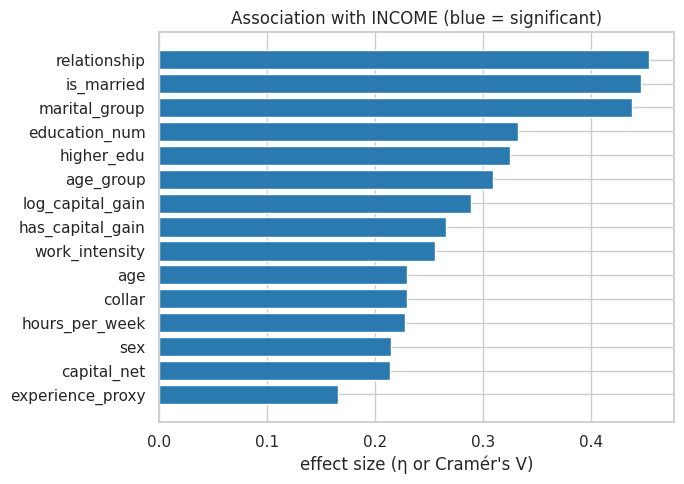

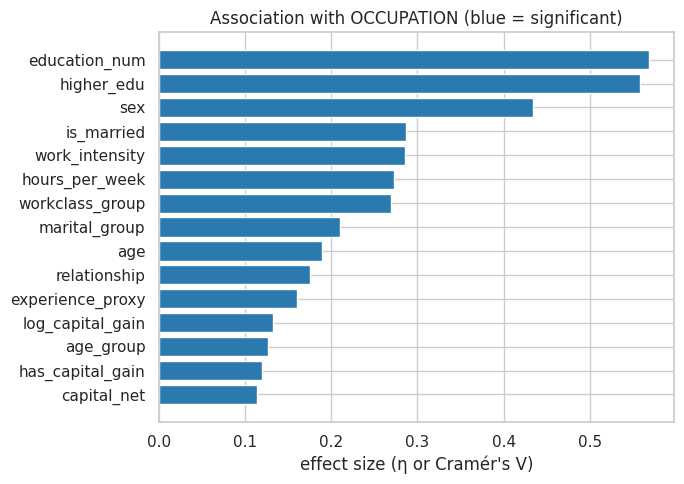

,feature,type,effect_size,p_value,significant (p<0.01)
0,relationship,categorical,0.4542,0.0000,True
1,is_married,categorical,0.4460,0.0000,True
2,marital_group,categorical,0.4381,0.0000,True
3,education_num,numeric,0.3328,0.0000,True
4,higher_edu,categorical,0.3249,0.0000,True
5,age_group,categorical,0.3096,0.0000,True
6,log_capital_gain,numeric,0.2892,0.0000,True
7,has_capital_gain,categorical,0.2658,0.0000,True
8,work_intensity,numeric,0.2556,0.0000,True
9,age,numeric,0.2301,0.0000,True


,feature,type,effect_size,p_value,significant (p<0.01)
0,education_num,numeric,0.5691,0.0,True
1,higher_edu,categorical,0.5579,0.0,True
2,sex,categorical,0.4339,0.0,True
3,is_married,categorical,0.2869,0.0,True
4,work_intensity,numeric,0.2858,0.0,True
5,hours_per_week,numeric,0.2728,0.0,True
6,workclass_group,categorical,0.2692,0.0,True
7,marital_group,categorical,0.2108,0.0,True
8,age,numeric,0.1898,0.0,True
9,relationship,categorical,0.1753,0.0,True


In [ ]:
def cramers_v(a, b):
    ct = pd.crosstab(a, b); chi2, p, _, _ = chi2_contingency(ct); n = ct.values.sum()
    r, k = ct.shape
    phi2 = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    rc, kc = r - ((r - 1) ** 2) / (n - 1), k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2 / max(1e-12, min(kc - 1, rc - 1))), p

def eta(x, g):
    grand = x.mean()
    ssb = sum(len(v) * (v.mean() - grand) ** 2 for _, v in x.groupby(g))
    return np.sqrt(ssb / ((x - grand) ** 2).sum())

def significance_table(d, target, num, cat_or_bin):
    rows = []
    for c in num:
        F, p = f_classif(d[[c]], d[target]); rows.append((c, "numeric", eta(d[c], d[target]), p[0]))
    for c in cat_or_bin:
        v, p = cramers_v(d[c], d[target]); rows.append((c, "categorical", v, p))
    t = pd.DataFrame(rows, columns=["feature", "type", "effect_size", "p_value"])
    t["significant (p<0.01)"] = t["p_value"] < 0.01
    return t.sort_values("effect_size", ascending=False).reset_index(drop=True)

num_f = ["age", "education_num", "hours_per_week", "log_capital_gain", "log_capital_loss",
         "capital_net", "experience_proxy", "work_intensity", "fnlwgt"]
cat_f = ["workclass_group", "marital_group", "relationship", "race", "region", "sex", "age_group",
         "is_married", "is_us_native", "has_capital_gain", "has_capital_loss", "higher_edu"]

# objective 2: income
sig_income = significance_table(fe, "income_bin", num_f, cat_f + ["collar"])
# objective 3: occupation (only rows with real labels, collar excluded because it is derived from it)
fe_occ = fe[fe["occ_observed"]]
sig_occ = significance_table(fe_occ, "occupation", num_f, cat_f)

def plot_sig(t, title):
    t = t.head(15).iloc[::-1]
    colors = t["significant (p<0.01)"].map({True: "#2a7ab0", False: "#bbbbbb"})
    plt.figure(figsize=(7, 5)); plt.barh(t["feature"], t["effect_size"], color=colors)
    plt.title(title); plt.xlabel("effect size (η or Cramér's V)"); plt.tight_layout(); plt.show()

plot_sig(sig_income, "Association with INCOME (blue = significant)")
plot_sig(sig_occ, "Association with OCCUPATION (blue = significant)")
display(sig_income.round(4)); display(sig_occ.round(4))

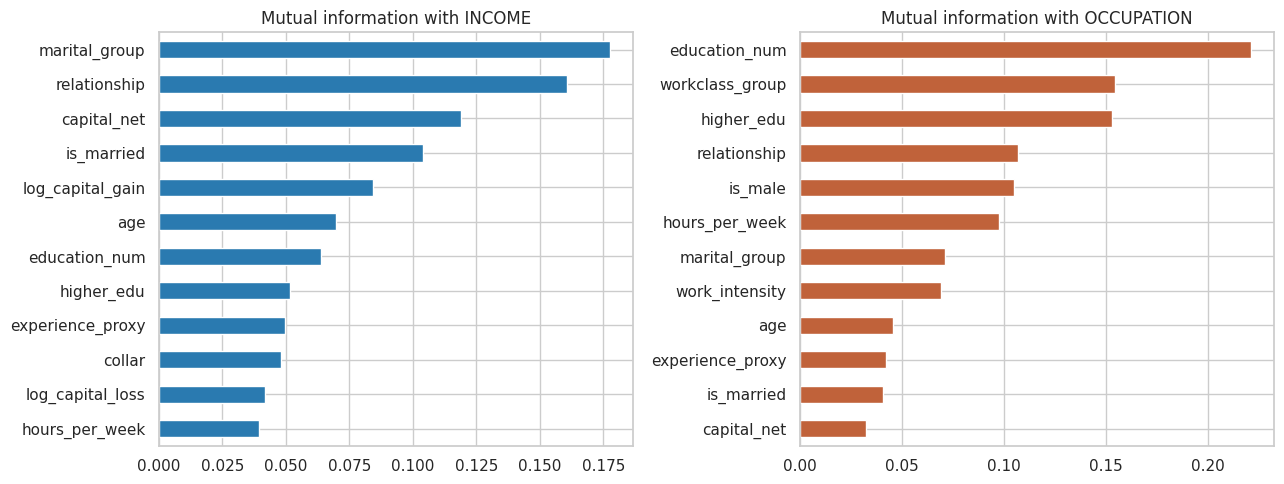

In [ ]:
# Mutual information (captures non-linear links), one-hot columns grouped back to parent feature
def mi_by_parent(X, y, parent, n=20000):
    idx = y.dropna().sample(min(n, y.notna().sum()), random_state=RANDOM_STATE).index
    disc = [c not in NUM for c in X.columns]
    mi = mutual_info_classif(X.loc[idx], y.loc[idx], discrete_features=disc, random_state=RANDOM_STATE)
    return pd.Series(mi, index=X.columns).groupby(parent).sum().sort_values(ascending=False)

mi_income = mi_by_parent(X_seg_s, y_income, parent_seg)
mi_occ    = mi_by_parent(X_occ_s, y_occ, parent_occ)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
mi_income.head(12).iloc[::-1].plot.barh(ax=ax[0], color="#2a7ab0", title="Mutual information with INCOME")
mi_occ.head(12).iloc[::-1].plot.barh(ax=ax[1], color="#c0623a", title="Mutual information with OCCUPATION")
plt.tight_layout(); plt.show()

###4.6 Remove redundant features and apply PCA

1. **Correlation filter:** drop one column of every pair with |r| > 0.90 (prints which and why).
2. **PCA** on the standardised matrix, keeping enough components for 95 % of variance.
3. **PCA loadings and a PCA-based feature importance** (sum of |loading| weighted by explained variance) show which original variables drive the retained components.

The target is not used here. It is only used for the colour of the sanity-check scatter.

[SEGMENTATION / INCOME matrix] correlated pairs removed: [('age', 'experience_proxy', np.float64(0.983)), ('log_capital_gain', 'has_capital_gain', np.float64(0.993)), ('log_capital_loss', 'has_capital_loss', np.float64(0.999)), ('capital_net', 'capital_gain_capped', np.float64(0.938)), ('workclass_missing', 'occupation_missing', np.float64(0.998)), ('is_married', 'marital_group_Married', np.float64(0.975)), ('is_us_native', 'region_North-America', np.float64(0.973))]
[SEGMENTATION / INCOME matrix] 43 cols -> 36 after filter -> 16 PCs (95.0% variance)


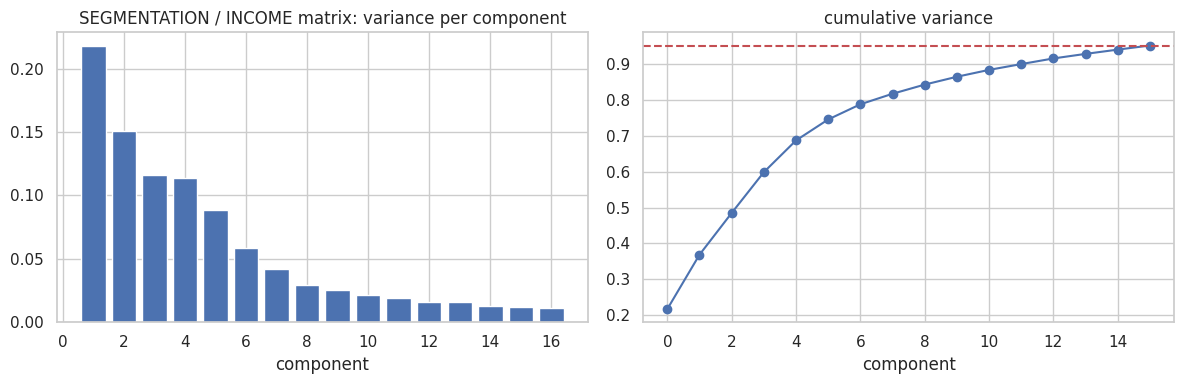

[OCCUPATION matrix] correlated pairs removed: [('age', 'experience_proxy', np.float64(0.983)), ('log_capital_gain', 'has_capital_gain', np.float64(0.993)), ('log_capital_loss', 'has_capital_loss', np.float64(0.999)), ('capital_net', 'capital_gain_capped', np.float64(0.938)), ('is_married', 'marital_group_Married', np.float64(0.975)), ('is_us_native', 'region_North-America', np.float64(0.973))]
[OCCUPATION matrix] 38 cols -> 32 after filter -> 15 PCs (95.9% variance)


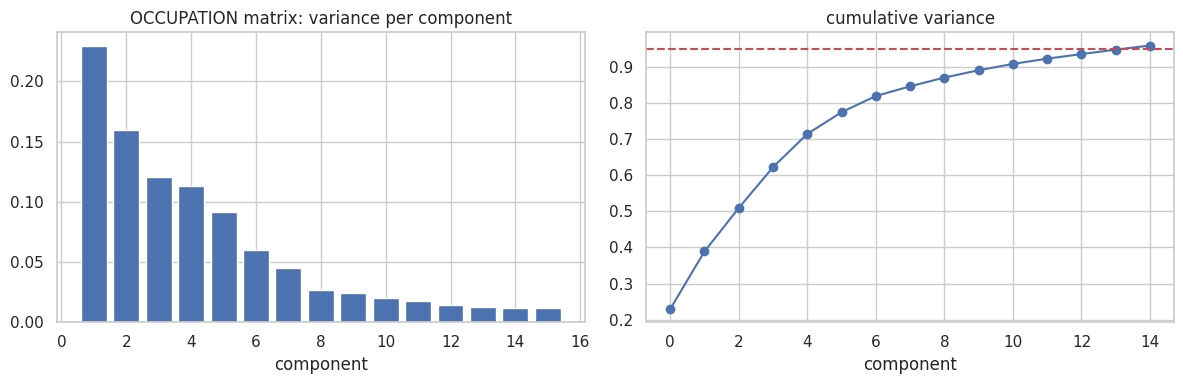

In [ ]:
def prune_correlated(X, thr=0.90):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = [(a, b, round(upper.loc[a, b], 3)) for b in upper.columns for a in upper.index
             if pd.notna(upper.loc[a, b]) and upper.loc[a, b] > thr]
    drop = sorted({b for _, b, _ in pairs})
    return X.drop(columns=drop), drop, pairs

def run_pca(X_scaled, parent, name, var=0.95):
    Xp, dropped, pairs = prune_correlated(X_scaled)
    print(f"[{name}] correlated pairs removed:", pairs if pairs else "none")
    pca = PCA(n_components=var, random_state=RANDOM_STATE).fit(Xp)
    Z = pd.DataFrame(pca.transform(Xp), index=X_scaled.index,
                     columns=[f"PC{i+1}" for i in range(pca.n_components_)])
    print(f"[{name}] {X_scaled.shape[1]} cols -> {Xp.shape[1]} after filter -> {pca.n_components_} PCs "
          f"({pca.explained_variance_ratio_.sum():.1%} variance)")

    # scree plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_)
    ax[0].set(title=f"{name}: variance per component", xlabel="component")
    ax[1].plot(np.cumsum(pca.explained_variance_ratio_), marker="o"); ax[1].axhline(var, ls="--", c="r")
    ax[1].set(title="cumulative variance", xlabel="component"); plt.tight_layout(); plt.show()

    loadings = pd.DataFrame(pca.components_.T, index=Xp.columns, columns=Z.columns)
    imp = (loadings.abs() * pca.explained_variance_ratio_).sum(axis=1)
    imp = imp.groupby(parent).sum().sort_values(ascending=False)
    return Xp, pca, Z, loadings, imp

Xp_seg, pca_seg, Z_seg, load_seg, pca_imp_seg = run_pca(X_seg_s, parent_seg, "SEGMENTATION / INCOME matrix")
Xp_occ, pca_occ, Z_occ, load_occ, pca_imp_occ = run_pca(X_occ_s, parent_occ, "OCCUPATION matrix")

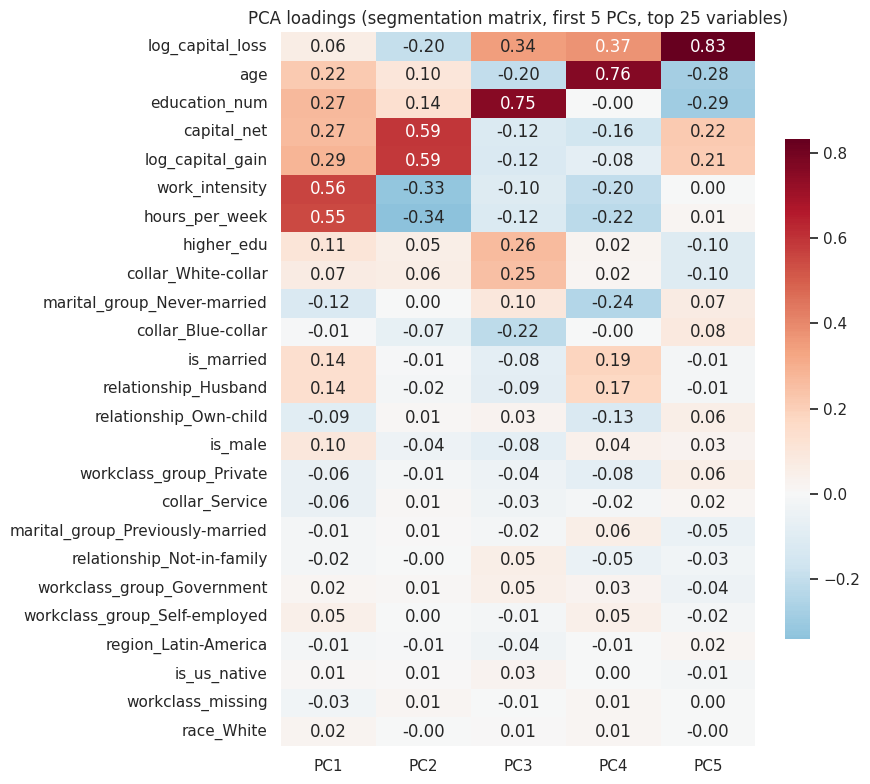

PC1  negative: ['marital_group_Never-married', 'relationship_Own-child', 'workclass_group_Private'] | positive: ['log_capital_gain', 'hours_per_week', 'work_intensity']
PC2  negative: ['hours_per_week', 'work_intensity', 'log_capital_loss'] | positive: ['education_num', 'log_capital_gain', 'capital_net']
PC3  negative: ['collar_Blue-collar', 'age', 'log_capital_gain'] | positive: ['higher_edu', 'log_capital_loss', 'education_num']


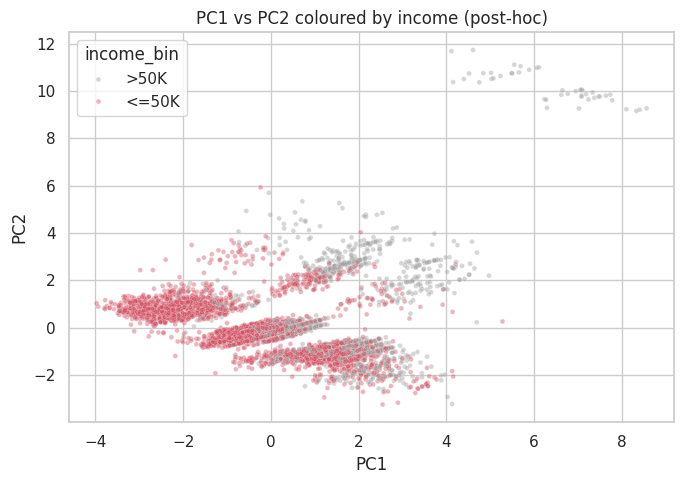

In [ ]:
# What does each of the first components mean?
plt.figure(figsize=(9, 8))
top = load_seg.iloc[:, :5].loc[load_seg.iloc[:, :5].abs().max(axis=1).sort_values(ascending=False).head(25).index]
sns.heatmap(top, cmap="RdBu_r", center=0, annot=True, fmt=".2f", cbar_kws={"shrink": .7})
plt.title("PCA loadings (segmentation matrix, first 5 PCs, top 25 variables)"); plt.tight_layout(); plt.show()

for pc in ["PC1", "PC2", "PC3"]:
    s = load_seg[pc].sort_values()
    print(f"{pc}  negative: {list(s.head(3).index)} | positive: {list(s.tail(3).index)}")

# Sanity check: do the unsupervised components already separate income? (colour only, not used in PCA)
plt.figure(figsize=(7, 5))
smp = Z_seg.sample(8000, random_state=RANDOM_STATE)
sns.scatterplot(x=smp["PC1"], y=smp["PC2"], hue=y_income.loc[smp.index].map({0: "<=50K", 1: ">50K"}),
                alpha=.4, s=12, palette=["#999999", "#d1495b"])
plt.title("PC1 vs PC2 coloured by income (post-hoc)"); plt.tight_layout(); plt.show()

###4.7 Feature importance (supervised check against each target)

A Random Forest is used as a probe. It is **not** the modelling goal, only a way to rank features against income and occupation. Two views are shown: impurity importance and permutation importance on held-out rows (more reliable). One-hot columns are summed back to their parent feature.

[INCOME] balanced accuracy on hold-out: 0.835


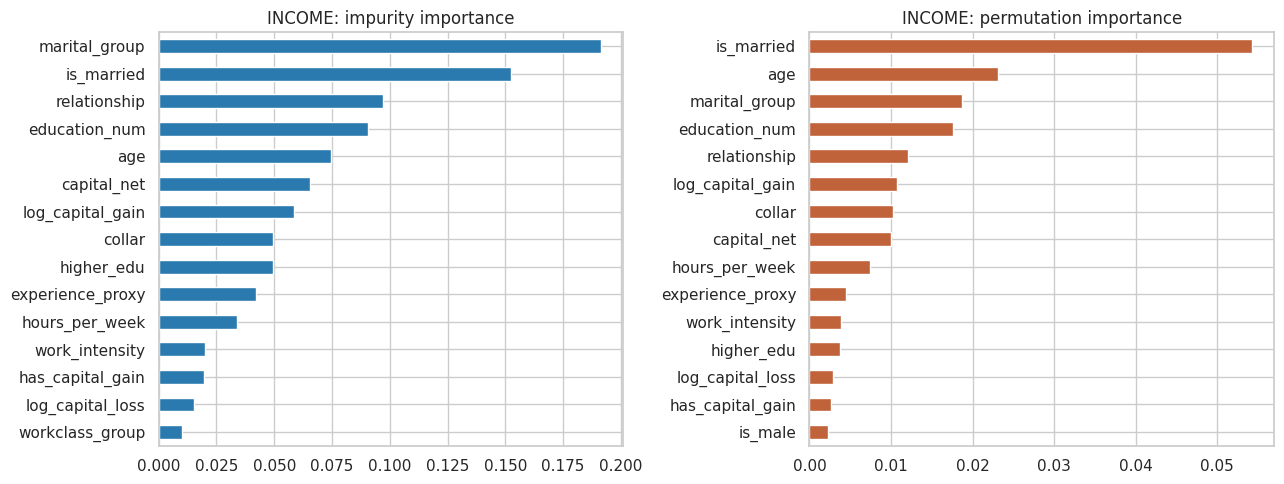

[OCCUPATION] balanced accuracy on hold-out: 0.304


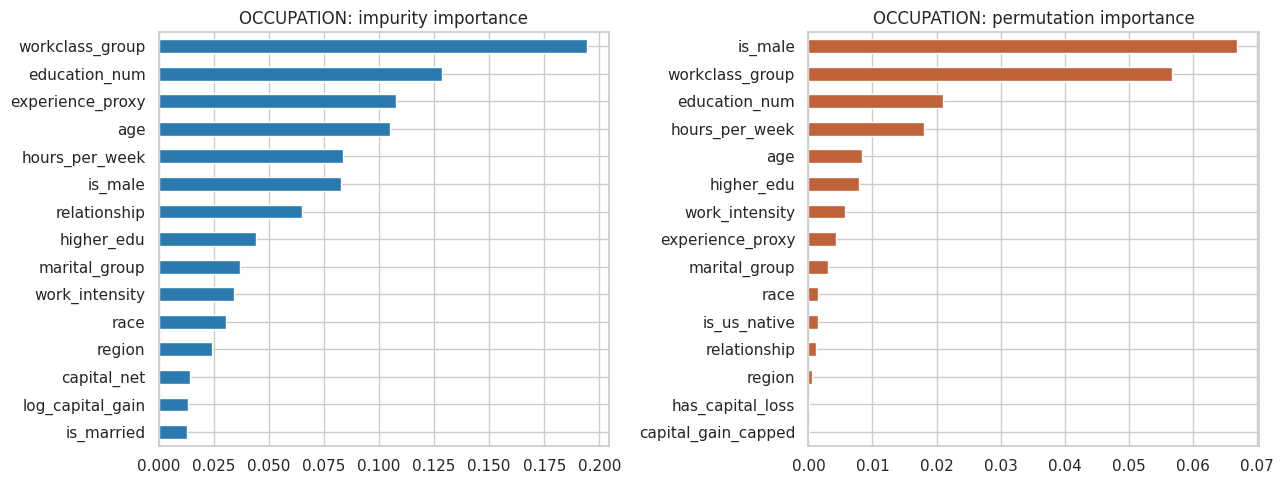

,impurity,permutation
is_married,0.1526,0.0542
age,0.0744,0.0231
marital_group,0.1914,0.0188
education_num,0.0906,0.0176
relationship,0.0972,0.0120
log_capital_gain,0.0587,0.0107
collar,0.0496,0.0103
capital_net,0.0656,0.0100
hours_per_week,0.0337,0.0074
experience_proxy,0.0423,0.0044


,impurity,permutation
is_male,0.0826,0.0669
workclass_group,0.1946,0.0567
education_num,0.1288,0.0211
hours_per_week,0.0837,0.0180
age,0.1050,0.0083
higher_edu,0.0442,0.0080
work_intensity,0.0342,0.0058
experience_proxy,0.1076,0.0043
marital_group,0.0368,0.0030
race,0.0307,0.0015


In [ ]:
def rf_importance(X, y, parent, name, top=15):
    mask = y.notna(); X, y = X[mask], y[mask]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
    rf = RandomForestClassifier(n_estimators=150, max_depth=14, min_samples_leaf=5, n_jobs=-1,
                                class_weight="balanced", random_state=RANDOM_STATE).fit(Xtr, ytr)
    from sklearn.metrics import balanced_accuracy_score
    print(f"[{name}] balanced accuracy on hold-out: {balanced_accuracy_score(yte, rf.predict(Xte)):.3f}")

    imp_gini = pd.Series(rf.feature_importances_, index=X.columns).groupby(parent).sum()
    idx = Xte.sample(min(5000, len(Xte)), random_state=RANDOM_STATE).index
    perm = permutation_importance(rf, Xte.loc[idx], yte.loc[idx], n_repeats=5, n_jobs=-1,
                                  scoring="balanced_accuracy", random_state=RANDOM_STATE)
    imp_perm = pd.Series(perm.importances_mean, index=X.columns).clip(lower=0).groupby(parent).sum()

    out = pd.DataFrame({"impurity": imp_gini, "permutation": imp_perm}).sort_values("permutation", ascending=False)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    out["impurity"].sort_values().tail(top).plot.barh(ax=ax[0], color="#2a7ab0", title=f"{name}: impurity importance")
    out["permutation"].sort_values().tail(top).plot.barh(ax=ax[1], color="#c0623a", title=f"{name}: permutation importance")
    plt.tight_layout(); plt.show()
    return out

imp_income = rf_importance(X_seg_s, y_income, parent_seg, "INCOME")
imp_occ    = rf_importance(X_occ_s, y_occ, parent_occ, "OCCUPATION")
display(imp_income.head(10).round(4)); display(imp_occ.head(10).round(4))

In [ ]:
# Consolidated ranking: one table per objective
summary_income = pd.DataFrame({
    "stat_effect": sig_income.set_index("feature")["effect_size"],
    "mutual_info": mi_income,
    "rf_permutation": imp_income["permutation"],
    "pca_weight": pca_imp_seg}).dropna(how="all").fillna(0)
summary_income = (summary_income / summary_income.max()).assign(
    mean_rank_score=lambda t: t.mean(axis=1)).sort_values("mean_rank_score", ascending=False)

summary_occ = pd.DataFrame({
    "stat_effect": sig_occ.set_index("feature")["effect_size"],
    "mutual_info": mi_occ,
    "rf_permutation": imp_occ["permutation"],
    "pca_weight": pca_imp_occ}).dropna(how="all").fillna(0)
summary_occ = (summary_occ / summary_occ.max()).assign(
    mean_rank_score=lambda t: t.mean(axis=1)).sort_values("mean_rank_score", ascending=False)

print("Top drivers of INCOME (objective 2)"); display(summary_income.head(10).round(3))
print("Top drivers of OCCUPATION (objective 3)"); display(summary_occ.head(10).round(3))

Top drivers of INCOME (objective 2)


,stat_effect,mutual_info,rf_permutation,pca_weight,mean_rank_score
relationship,1.000,0.903,0.222,1.000,0.781
is_married,0.982,0.584,1.000,0.356,0.731
marital_group,0.965,1.000,0.346,0.570,0.720
education_num,0.733,0.359,0.324,0.720,0.534
capital_net,0.472,0.668,0.184,0.770,0.524
age,0.507,0.392,0.426,0.767,0.523
log_capital_gain,0.637,0.475,0.198,0.741,0.513
collar,0.507,0.270,0.190,0.821,0.447
hours_per_week,0.501,0.222,0.137,0.777,0.409
work_intensity,0.563,0.184,0.071,0.763,0.395


Top drivers of OCCUPATION (objective 3)


,stat_effect,mutual_info,rf_permutation,pca_weight,mean_rank_score
education_num,1.000,1.000,0.315,0.725,0.760
workclass_group,0.473,0.698,0.847,0.558,0.644
higher_edu,0.980,0.691,0.119,0.285,0.519
hours_per_week,0.479,0.441,0.269,0.834,0.506
relationship,0.308,0.484,0.018,1.000,0.452
is_male,0.000,0.474,1.000,0.306,0.445
work_intensity,0.502,0.312,0.086,0.820,0.430
age,0.334,0.207,0.124,0.804,0.367
marital_group,0.370,0.323,0.045,0.591,0.332
capital_net,0.201,0.148,0.000,0.795,0.286


###4.8 Export the prepared datasets

Outputs ready for the clustering step:
- `prep_segmentation_pca.csv`: PCA scores for objectives 1 and 2 (income kept only as a profiling column)
- `prep_occupation_pca.csv`: PCA scores for objective 3 (rows with real occupation labels flagged)
- `prep_full_encoded.csv`: scaled encoded matrix before PCA, plus the original readable columns for profiling

In [ ]:
seg_out = Z_seg.copy()
seg_out["income"] = fe["income"]; seg_out["sample_weight"] = fe["fnlwgt"]
seg_out.to_csv("prep_segmentation_pca.csv", index=False)

occ_out = Z_occ.copy()
occ_out["occupation"] = y_occ; occ_out["occupation_observed"] = fe["occ_observed"]
occ_out["sample_weight"] = fe["fnlwgt"]
occ_out.to_csv("prep_occupation_pca.csv", index=False)

pd.concat([X_seg_s, fe[["age_group", "occupation", "income", "fnlwgt"]]], axis=1).to_csv(
    "prep_full_encoded.csv", index=False)

print("Segmentation PCA :", seg_out.shape)
print("Occupation PCA   :", occ_out.shape)
print("Saved 3 CSV files.")

Segmentation PCA : (48790, 18)
Occupation PCA   : (48790, 18)
Saved 3 CSV files.


modeling

## 5. Segmentation


The objective of this modeling phase is to segment individuals into distinct groups based on their demographic, financial, educational, and lifestyle characteristics.

5.1 Load the segmentation dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
df_seg = pd.read_csv("prep_segmentation_pca.csv")

print("Dataset shape:", df_seg.shape)
df_seg.head()

Dataset shape: (48790, 18)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,income,sample_weight
0,1.116613,2.094727,1.041851,-0.518163,-0.066707,-0.386952,1.947691,0.464078,-1.026262,0.673440,-0.095178,0.363171,0.040784,0.112339,0.231418,0.197695,<=50K,77516
1,-1.328798,1.404055,1.341412,1.862202,-1.099255,1.221451,-0.310523,-0.066957,-0.535319,0.321403,0.238198,0.111911,-0.234736,0.100740,-0.257770,-0.550722,<=50K,83311
2,-0.455239,-0.336392,-0.637330,-0.129128,-0.057823,-0.580624,-0.073694,1.014569,0.237677,-0.084178,0.701195,0.487099,-0.122669,0.276631,-0.020542,0.069432,<=50K,215646
3,-0.152936,-0.358504,-1.660894,1.040572,-0.083458,0.446596,-0.211026,0.225530,0.175176,-0.486490,-0.965080,0.352860,-0.471006,-0.046301,0.149481,0.366591,<=50K,234721
4,0.009697,0.018071,1.308507,-0.523586,-0.534053,0.303739,-0.098213,-0.658311,0.448908,-1.134304,-0.774851,0.634333,-0.267019,-0.979302,-0.209503,-0.658332,<=50K,338409


We see a dataset of 48,790 individuals and 18 columns (reduced via Principal Component Analysis, including an income target variable and sample weights) being prepared for clustering using the K-Means algorithm, with cluster quality evaluated by the Silhouette score

5.2 Select the PCA features

In [ ]:
pc_cols = [col for col in df_seg.columns if col.startswith("PC")]

X = df_seg[pc_cols]

print("Number of individuals:", X.shape[0])
print("Number of PCA components:", X.shape[1])
print("PCA features:", pc_cols)

Number of individuals: 48790
Number of PCA components: 16
PCA features: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16']


We see that the code selects and isolates the 16 principal components (PC1 to PC16) from the dataset of 48,790 individuals into a matrix X to prepare the features for the upcoming clustering mode

5.3 Choosing the number of clusters

In [ ]:
inertias = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(
            X,
            labels,
            sample_size=10000,
            random_state=42
        )
    )

results_k = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results_k

,K,Inertia,Silhouette Score
0,2,410233.745426,0.173158
1,3,356926.355740,0.166337
2,4,310714.649511,0.174908
3,5,280778.084749,0.171802
4,6,244097.646922,0.192380
5,7,224008.163846,0.189457
6,8,207106.397667,0.184974


We see a loop iterating through a range of clusters ($K$ from 2 to 8) to run the K-Means algorithm on matrix $X$, computing the inertia and the Silhouette score on a sample of 10,000 individuals. The results show that inertia decreases as $K$ increases, while the Silhouette score reaches its peak at **0.192** for **$K = 6$ clusters**.

5.4 Elbow Method

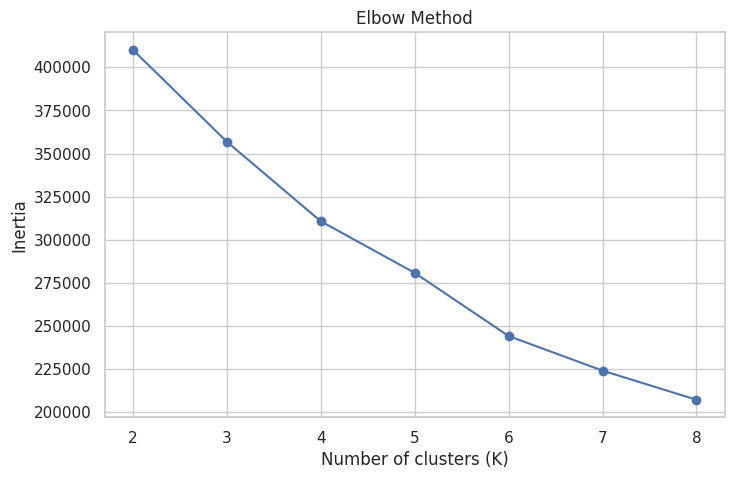

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

We see an elbow method plot showing the relationship between inertia and the number of clusters ($K$ from 2 to 8). As $K$ increases, inertia decreases continuously, with the slope starting to bend around $K = 4$ and leveling off more visibly near $K = 6$.

5.5 Silhouette Score

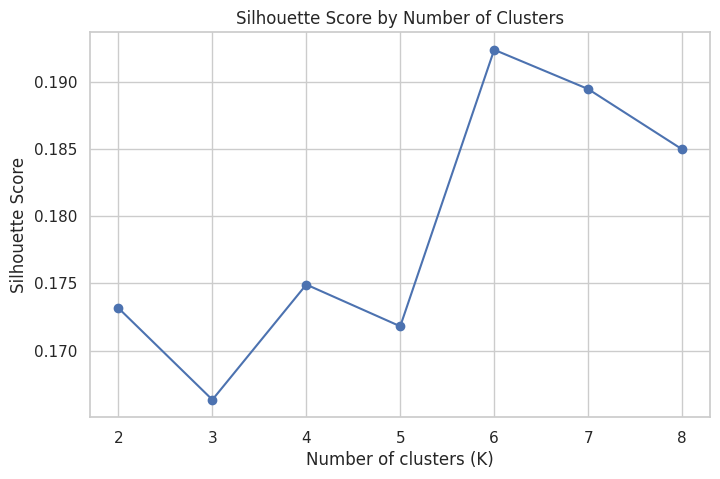

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(list(K_range))
plt.grid(True)

plt.show()

We see a plot showing the Silhouette score across different numbers of clusters ($K$ from 2 to 8). The score reaches its peak at approximately **0.192** for **$K = 6$ clusters**, confirming that 6 is the optimal number of groups for this dataset.

5.6 Best K according to Silhouette Score

In [ ]:
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

best_k = K_range[np.argmax(silhouette_scores)]

print("\nBest K according to Silhouette Score:", best_k)
print(
    "Best Silhouette Score:",
    round(max(silhouette_scores), 4)
)

K=2: Silhouette Score=0.1732
K=3: Silhouette Score=0.1663
K=4: Silhouette Score=0.1749
K=5: Silhouette Score=0.1718
K=6: Silhouette Score=0.1924
K=7: Silhouette Score=0.1895
K=8: Silhouette Score=0.1850

Best K according to Silhouette Score: 6
Best Silhouette Score: 0.1924


We see the printed output displaying the Silhouette scores rounded to 4 decimal places for each cluster size ($K$ from 2 to 8). The code uses `np.argmax` to automatically select the optimal value, confirming that the best configuration is **$K = 6$ clusters** with a maximum Silhouette score of **0.1924**.

5.7 Selection of K

In [ ]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

df_seg["cluster"] = kmeans.fit_predict(X)

print(df_seg["cluster"].value_counts().sort_index())

cluster
0     2282
1    14630
2    19280
3     8657
4     3697
5      244
Name: count, dtype: int64


We see the execution of the final K-Means model configured with **$K = 6$ clusters** (`random_state=42`, `n_init=10`) on matrix $X$, storing the resulting cluster labels in a new column `cluster`. The printed cluster distribution shows varying cluster sizes: **cluster 2** is the largest with **19,280 individuals**, **cluster 1** contains **14,630**, followed by **cluster 3** (8,657), **cluster 4** (3,697), **cluster 0** (2,282), and **cluster 5** as a minority group with only **244 individuals**.

5.8 Evaluate the final clustering

In [ ]:
final_silhouette = silhouette_score(
    X,
    df_seg["cluster"],
    sample_size=10000,
    random_state=42
)

print("Final Silhouette Score:", round(final_silhouette, 4))

Final Silhouette Score: 0.1924


We see the calculation and evaluation of the final Silhouette score on a sample of 10,000 individuals using the newly assigned cluster labels in `df_seg["cluster"]`. The printed result confirms a final Silhouette score of **0.1924**, validating the overall cohesion and separation of the final 6-cluster solution.

5.9 Visualize the clusters

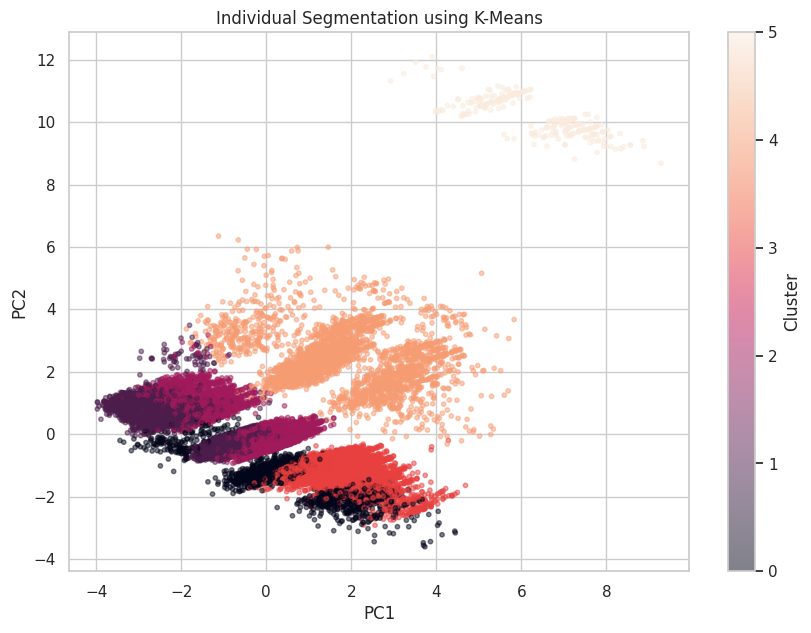

In [ ]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df_seg["PC1"],
    df_seg["PC2"],
    c=df_seg["cluster"],
    s=10,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Individual Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.show()

We see the scatter plot of individual segmentation projected onto the first two principal components (`PC1` and `PC2`), colored by the 6 clusters (0 to 5). The visualization highlights a distinct separation among groups: most individuals form a dense central core partitioned into multiple sub-clusters, while cluster 5 stands out as small, isolated groups at the top of the plot (higher `PC2` values).


5.10 Cluster size analysis

In [ ]:
cluster_sizes = (
    df_seg["cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    cluster_sizes / len(df_seg) * 100
).round(2)

cluster_summary = pd.DataFrame({
    "Number of individuals": cluster_sizes,
    "Percentage": cluster_percentages
})

cluster_summary

,Number of individuals,Percentage
cluster,,
0,2282,4.68
1,14630,29.99
2,19280,39.52
3,8657,17.74
4,3697,7.58
5,244,0.50


We see a summary dataframe calculating the absolute size and percentage distribution of individuals across the 6 clusters:

* **Cluster 2** forms the largest segment with **19,280 individuals (39.52%)**.


* **Cluster 1** represents the second largest group with **14,630 individuals (29.99%)**.


* **Cluster 3** accounts for **8,657 individuals (17.74%)**.


* **Cluster 4** contains **3,697 individuals (7.58%)**.


* **Cluster 0** includes **2,282 individuals (4.68%)**.


* **Cluster 5** is a minor segment comprising only **244 individuals (0.50%)**.

5.11 Income distribution by cluster

In [ ]:
income_distribution = pd.crosstab(
    df_seg["cluster"],
    df_seg["income"],
    normalize="index"
) * 100

income_distribution.round(2)

income,<=50K,>50K
cluster,,
0,49.87,50.13
1,98.09,1.91
2,74.97,25.03
3,66.03,33.97
4,39.22,60.78
5,0.00,100.00


We see a contingency table analyzing the percentage distribution of income levels (`<=50K` and `>50K`) across each cluster:

* **Cluster 5** consists exclusively of high earners, with **100.00%** of individuals earning **>50K**.


* **Cluster 4** is predominantly high-income, with **60.78%** earning **>50K** and **39.22%** earning **<=50K**.


* **Cluster 0** is evenly balanced, with **50.13%** earning **>50K** and **49.87%** earning **<=50K**.


* **Cluster 3** skews toward lower income, with **66.03%** earning **<=50K** and **33.97%** earning **>50K**.


* **Cluster 2** is mostly lower income, with **74.97%** earning **<=50K** and **25.03%** earning **>50K**.


* **Cluster 1** consists almost entirely of lower earners, with **98.09%** earning **<=50K** and only **1.91%** earning **>50K**.

5.12 Income Distribution by Cluster

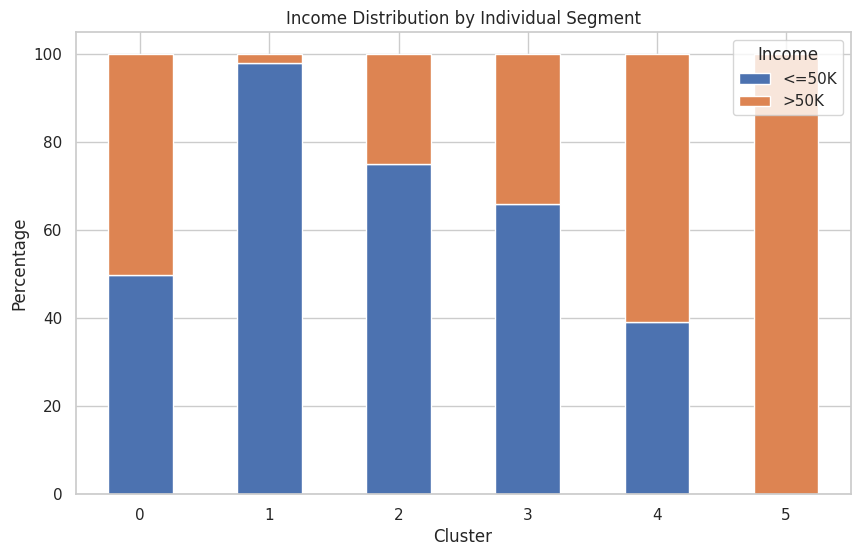

In [ ]:
income_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.title("Income Distribution by Individual Segment")
plt.legend(title="Income")
plt.xticks(rotation=0)

plt.show()

We see a stacked bar chart illustrating the percentage distribution of income levels (`<=50K` in blue and `>50K` in orange) for each individual segment (clusters 0 to 5). The visualization confirms the strong income disparity across groups: cluster 5 consists exclusively of individuals earning over 50K (100% orange), cluster 4 is predominantly high-income (61% orange), cluster 0 shows a perfectly balanced distribution (~50% for each category), while clusters 2, 3, and especially 1 are dominated by lower-income individuals (up to over 98% `<=50K` for cluster 1).

## 6. Classification


The classification objective is to build a predictive model capable of estimating an individual's income category `<=50K or >50K` from their characteristics.

###6.1 Classification Data Preparation

In [ ]:
import pandas as pd

df_clean = pd.read_csv("prep_segmentation_pca.csv")

print("Shape:", df_clean.shape)
display(df_clean.head())


Shape: (48790, 18)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,income,sample_weight
0,1.116613,2.094727,1.041851,-0.518163,-0.066707,-0.386952,1.947691,0.464078,-1.026262,0.673440,-0.095178,0.363171,0.040784,0.112339,0.231418,0.197695,<=50K,77516
1,-1.328798,1.404055,1.341412,1.862202,-1.099255,1.221451,-0.310523,-0.066957,-0.535319,0.321403,0.238198,0.111911,-0.234736,0.100740,-0.257770,-0.550722,<=50K,83311
2,-0.455239,-0.336392,-0.637330,-0.129128,-0.057823,-0.580624,-0.073694,1.014569,0.237677,-0.084178,0.701195,0.487099,-0.122669,0.276631,-0.020542,0.069432,<=50K,215646
3,-0.152936,-0.358504,-1.660894,1.040572,-0.083458,0.446596,-0.211026,0.225530,0.175176,-0.486490,-0.965080,0.352860,-0.471006,-0.046301,0.149481,0.366591,<=50K,234721
4,0.009697,0.018071,1.308507,-0.523586,-0.534053,0.303739,-0.098213,-0.658311,0.448908,-1.134304,-0.774851,0.634333,-0.267019,-0.979302,-0.209503,-0.658332,<=50K,338409


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48790 entries, 0 to 48789
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PC1            48790 non-null  float64
 1   PC2            48790 non-null  float64
 2   PC3            48790 non-null  float64
 3   PC4            48790 non-null  float64
 4   PC5            48790 non-null  float64
 5   PC6            48790 non-null  float64
 6   PC7            48790 non-null  float64
 7   PC8            48790 non-null  float64
 8   PC9            48790 non-null  float64
 9   PC10           48790 non-null  float64
 10  PC11           48790 non-null  float64
 11  PC12           48790 non-null  float64
 12  PC13           48790 non-null  float64
 13  PC14           48790 non-null  float64
 14  PC15           48790 non-null  float64
 15  PC16           48790 non-null  float64
 16  income         48790 non-null  object 
 17  sample_weight  48790 non-null  int64  
dtypes: flo

In [ ]:
# ==========================================
# VERIFICATION OF MISSING VALUES
# ==========================================

def check_missing_values(data):
    missing = data.isnull().sum()
    total_missing = missing.sum()

    print("Total missing values:", total_missing)

    if total_missing == 0:
        print("The dataset contains no missing values.")
    else:
        print("The dataset contains missing values:")
        print(missing[missing > 0])

check_missing_values(df_clean)

Total missing values: 0
The dataset contains no missing values.


In [ ]:
print(df_clean.columns.tolist())

['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'income', 'sample_weight']


In [ ]:
print(df_clean["income"].value_counts())

income
<=50K    37109
>50K     11681
Name: count, dtype: int64


The dataset prepared for classification contains **48,790 observations** and **16 principal components**. The target variable is `income`, which contains two classes: `<=50K` and `>50K`.

The `sample_weight` variable was excluded from the predictors because it represents a survey weighting factor rather than an individual's socio-economic characteristic. The principal components were retained as explanatory variables because they summarize the information contained in the original transformed variables.


###6.2 Definition of Predictors and Target Variable

In [ ]:
# Séparation des variables explicatives et de la cible

X = df_clean.drop(columns=["income", "sample_weight"])
#X = df_clean.drop(columns=["income"])
y = df_clean["income"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

print("\nVariables explicatives :")
print(X.columns.tolist())

print("\nDistribution de la cible :")
print(y.value_counts())

Shape de X : (48790, 16)
Shape de y : (48790,)

Variables explicatives :
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16']

Distribution de la cible :
income
<=50K    37109
>50K     11681
Name: count, dtype: int64


###6.3 Encoding the Target Variable

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes :", label_encoder.classes_)

Classes : ['<=50K' '>50K']


In [ ]:
print("\nEncoded target distribution:")
print(pd.Series(y_encoded).value_counts())


Encoded target distribution:
0    37109
1    11681
Name: count, dtype: int64


The target variable contains two categorical classes: `<=50K` and `>50K`. Label encoding converts these categories into numerical values so that they can be used by the classification algorithms.

The two income categories are therefore represented numerically while preserving the original class distinction.


###6.4 Splitting the Dataset into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set :", X_train.shape)
print("Testing set  :", X_test.shape)

Training set : (39032, 16)
Testing set  : (9758, 16)


The dataset was divided into a training set containing **80% of the observations** and a testing set containing **20%**.

Stratification was applied to preserve the distribution of the two income classes in both subsets. The training set is used to build the models, while the testing set is used to evaluate their performance on unseen data.


###6.5 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_train)

array([[ 0.04731312, -0.20484521, -0.22880644, ..., -0.35729974,
         0.30711561,  0.50013963],
       [-0.35175042, -0.06788281,  0.24923796, ..., -0.44096585,
         0.26786417,  0.46317904],
       [-0.26433567, -0.03533026, -0.0697512 , ..., -0.44460708,
         1.34093104,  1.02849066],
       ...,
       [ 0.47683191,  1.61263169,  1.02809124, ...,  0.9314301 ,
        -1.73220558, -2.53812045],
       [ 0.95934307, -1.09153924, -0.59526872, ..., -3.39704321,
         1.05813167,  0.25889256],
       [-0.10742266, -0.17636639, -0.71210543, ...,  0.51239726,
         1.06779162,  0.5978239 ]])

In [ ]:
scaler.transform(X_test)

array([[-0.31363982, -0.25507574, -0.62606652, ...,  0.96695622,
        -0.03494981,  0.81157593],
       [-1.15151893,  1.1032496 , -0.33466929, ..., -0.09633746,
         0.54749024,  0.17206795],
       [-1.27617276,  0.90651982, -0.46214588, ...,  0.04755193,
        -0.04915028,  0.06575612],
       ...,
       [-0.12420617, -0.03381781,  0.80640516, ...,  0.93635992,
        -1.43842397, -0.56527436],
       [ 0.48890292, -0.974337  , -2.41627711, ...,  0.70676667,
         0.52098187, -3.35621483],
       [ 0.80045548,  1.83407949, -0.50794632, ...,  0.68194551,
        -0.19489164,  0.576576  ]])

###6.6 Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

####6.6.1 Logistic Regression Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression")
print("-------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=label_encoder.classes_
))

Logistic Regression
-------------------
Accuracy : 0.8499
Precision: 0.7325
Recall   : 0.5873
F1-score : 0.6519

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      7422
        >50K       0.73      0.59      0.65      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.76      0.78      9758
weighted avg       0.84      0.85      0.84      9758



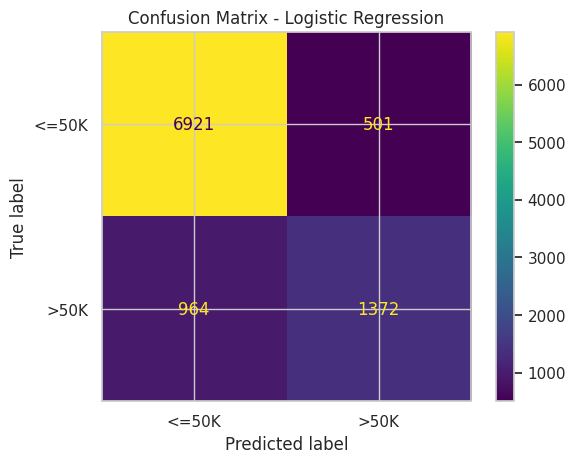

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Logistic Regression achieves an accuracy of **84.99%**. It performs particularly well for the `<=50K` class, with a recall of approximately **93%**.

For the `>50K` class, the model achieves a precision of **73.25%**, a recall of **58.73%**, and an F1-score of **65.19%**. This indicates that the model is able to identify a significant proportion of higher-income individuals, but it still misses some observations belonging to this class.

Overall, Logistic Regression provides a strong baseline for the classification task and shows that the principal components contain useful information for predicting income level.


###6.7 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Création du modèle
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Entraînement
tree_model.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree_model.predict(X_test)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


####6.7.1 Decision Tree Evaluation

In [ ]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("---------------------")
print(f"Accuracy : {accuracy_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall   : {recall_tree:.4f}")
print(f"F1-score : {f1_tree:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=label_encoder.classes_
))

Decision Tree Results
---------------------
Accuracy : 0.8434
Precision: 0.6967
Recall   : 0.6126
F1-score : 0.6519

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      7422
        >50K       0.70      0.61      0.65      2336

    accuracy                           0.84      9758
   macro avg       0.79      0.76      0.78      9758
weighted avg       0.84      0.84      0.84      9758



The Decision Tree achieves an accuracy of **84.34%**, which is slightly lower than the Logistic Regression baseline.

For the `>50K` class, the model achieves a precision of **69.67%** and a recall of **61.26%**. Its recall is slightly higher than that of Logistic Regression, meaning that it identifies a greater proportion of individuals belonging to the `>50K` category.

However, the model has lower precision and lower overall accuracy than Logistic Regression. Therefore, with the selected maximum depth of 10, the Decision Tree does not provide a significant overall improvement.


###6.8 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


####6.8.1 Random Forest Evaluation

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_
))

Random Forest Results
---------------------
Accuracy : 0.8575
Precision: 0.7564
Recall   : 0.5967
F1-score : 0.6671

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7422
        >50K       0.76      0.60      0.67      2336

    accuracy                           0.86      9758
   macro avg       0.82      0.77      0.79      9758
weighted avg       0.85      0.86      0.85      9758



The Random Forest achieves the highest overall accuracy among the three tested models, with **85.75%**.

For the `>50K` class, it achieves a precision of **75.64%**, a recall of **59.67%**, and an F1-score of **66.71%**. It therefore provides the highest precision and F1-score among the tested models.

Although the Decision Tree has a slightly higher recall for the `>50K` class, Random Forest provides a better overall balance between the different evaluation metrics.


###6.9 Comparison of Classification Models

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_tree,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_tree,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_tree,
        recall_rf
    ],
    "F1-score": [
        f1,
        f1_tree,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.849867,0.732515,0.587329,0.651936
1,Decision Tree,0.843411,0.696689,0.612586,0.651936
2,Random Forest,0.857450,0.756375,0.596747,0.667145


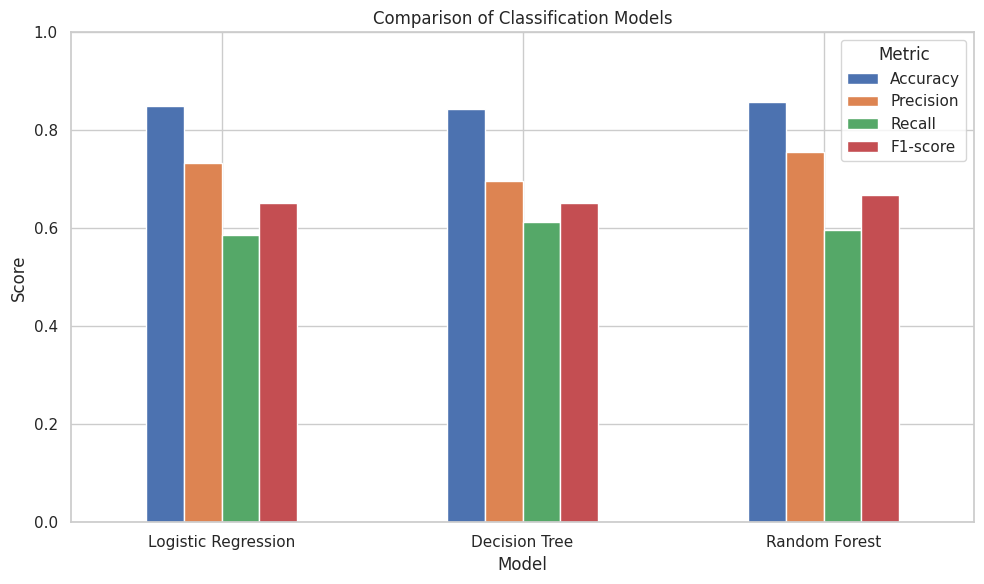

In [ ]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

The three classification models show relatively similar performance, with accuracy values between **84.34% and 85.75%**.

The **Random Forest** provides the best overall performance, achieving the highest accuracy (**85.75%**), precision (**75.64%**), and F1-score (**66.71%**).

The **Decision Tree** achieves the highest recall for the `>50K` class (**61.26%**), meaning that it identifies slightly more individuals belonging to this income category. However, its precision and overall accuracy are lower.

Logistic Regression provides a strong baseline, with an accuracy of **84.99%** and an F1-score of **65.19%**.

Therefore, among the three tested models, **Random Forest is selected as the best-performing classification model** because it provides the best overall balance of accuracy, precision, and F1-score.


###6.10 Classification Conclusion

The classification stage aimed to predict an individual's income category using the information represented by the principal components.

Three models were evaluated: Logistic Regression, Decision Tree, and Random Forest. The results show that all three models achieve an accuracy above **84%**, indicating that the transformed data contains useful information for predicting income level.

Among the tested approaches, **Random Forest provides the best overall performance**, with an accuracy of **85.75%** and an F1-score of **66.71%** for the classification task. It is therefore selected as the final classification model.

However, the lower recall obtained for the `>50K` class shows that predicting the higher-income category remains more difficult than predicting the `<=50K` category. This is partly related to the imbalanced distribution of the target variable.


## 7. Evaluation and interpretation of the results


## 8. Conclusion